# imports

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.io import readsav
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import RFE
import itertools
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error
from sklearn.mixture import BayesianGaussianMixture
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import KFold, cross_val_score




# create '/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv'

In [3]:
path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'
data = readsav(path, verbose=False)
tr_struct = data['tr'][0]
tr_dict = {name: tr_struct[name] for name in tr_struct.dtype.names}
tr_df = pd.DataFrame(tr_dict)
tr_df.to_csv('tr_df.csv', index=False)
print(os.getcwd())

data = readsav(path, verbose=False)
mp_struct = data['mp'][0]
mp_dict = {name: mp_struct[name] for name in mp_struct.dtype.names}
mp_df = pd.DataFrame(mp_dict)
mp_df.to_csv('mp_df.csv', index=False)
print(os.getcwd())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'

In [ ]:


# 1. Define your original CSV filepaths
mp_filepath = r'/Users/aldensantoso/Documents/plasma_research/ML Project/mp_df.csv'
tr_filepath = r'/Users/aldensantoso/Documents/plasma_research/ML Project/tr_df.csv'

# 2. Load the CSV datasets
print("Loading CSV datasets...")
mp_df = pd.read_csv(mp_filepath)
tr_df = pd.read_csv(tr_filepath)

# 3. Identify the shared shot column dynamically
mp_cols = set(mp_df.columns)
tr_cols = set(tr_df.columns)
common_columns = mp_cols.intersection(tr_cols)

shot_key = None
for col in common_columns:
    if 'shot' in col.lower():
        shot_key = col
        break

# 4. Merge the two datasets cleanly
if shot_key:
    combined_df = pd.merge(mp_df, tr_df, on=shot_key, how='inner')
    print(f"Successfully merged using alignment key: '{shot_key}'")
else:
    # Fallback to horizontal concatenation if row sizes align
    combined_df = pd.concat([mp_df, tr_df], axis=1)
    combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
    print("No common shot key found. Concatenated datasets side-by-side.")

# 5. Export to the destination project path
destination_path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv'
combined_df.to_csv(destination_path, index=False)
print(f"mp dimensions {mp_df.shape}")
print(f"tr dimensions {tr_df.shape}")
print(f"\n[SUCCESS] New matrix created with dimensions: {combined_df.shape}")
print(f"Saved successfully to your machine at:\n--> {destination_path}")

Loading CSV datasets...
No common shot key found. Concatenated datasets side-by-side.
mp dimensions (1051, 35)
tr dimensions (1051, 24)

[SUCCESS] New matrix created with dimensions: (1051, 47)
Saved successfully to your machine at:
--> /Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv


In [ ]:


def clean_combined_csv(in_csv=None, out_csv=None):
  if in_csv is None:
    in_csv = (
        "/Users/aldensantoso/Documents/plasma_research/ML"
        " Project/combined_plasma_data_clean.csv"
    )
  if out_csv is None:
    out_csv = in_csv.replace(".csv", "_clean.csv")

  if not os.path.exists(in_csv):
    raise FileNotFoundError(in_csv)

  df = pd.read_csv(in_csv)
  df.columns = df.columns.str.strip().str.replace("\ufeff", "")

  # 1. REMOVE DERIVED FEATURES FROM PIPELINE IMMEDIATELY
  derived_to_remove = ["v_A_proxy", "f_norm", "n_norm", "dB2"]
  df = df.drop(columns=[c for c in derived_to_remove if c in df.columns])

  # ...existing code...
  # exact-header candidates (single-element tuples must include trailing comma)
  etau_keys = ("ETAU",)
  nes_keys = ("NES",)
  avgmodef_keys = ("AVGMODEF",)
  avgmodef2_keys = ("AVGMODEF2",)
  bzxr_keys = ("BZXR",)
  te_keys = ("TE",)
  pvol_keys = ("PVOL",)
  raxis_keys = ("RAXIS",)
  tex_keys = ("TEX",)

  etau_col = next((c for c in etau_keys if c in df.columns), None)
  nes_col = next((c for c in nes_keys if c in df.columns), None)
  avgmodef_col = next((c for c in avgmodef_keys if c in df.columns), None)
  avgmodef2_col = next((c for c in avgmodef2_keys if c in df.columns), None)
  bzxr_col = next((c for c in bzxr_keys if c in df.columns), None)
  te_col = next((c for c in te_keys if c in df.columns), None)
  pvol_col = next((c for c in pvol_keys if c in df.columns), None)
  raxis_col = next((c for c in raxis_keys if c in df.columns), None)
  tex_col = next((c for c in tex_keys if c in df.columns), None)

  # fallback: try case-insensitive alternatives
  if etau_col is None:
    etau_col = next((c for c in df.columns if c.strip().lower() in ("etau", "tau_e", "taue")), None)
  if etau_col is None:
    raise KeyError("ETAU / tau_e column not found in CSV")

  if nes_col is None:
    nes_col = next((c for c in df.columns if c.strip().lower() in ("nes", "ne", "n_e")), None)
  if nes_col is None:
    raise KeyError("Electron density column (NES / NE) not found in CSV")
# ...existing code...

  # Coerce numeric where possible
  for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

  # Replace infinities
  df = df.replace([np.inf, -np.inf], np.nan)

  # Enforce physics filters
  df = df[df[etau_col] > 0].copy()  # ETAU > 0
  df = df[df[nes_col] > 0].copy()  # NES / n_e > 0
  df = df[df[avgmodef_col] > 0].copy()  
  df = df[df[avgmodef2_col] > 0].copy()
  df = df[df[bzxr_col] > 0].copy()  
  df = df[df[te_col] > 0].copy()
  df = df[df[pvol_col] > 0].copy() 
  df = df[df[raxis_col] > 0].copy()
  df = df[df[tex_col] > 0].copy() 

  # Drop NaNs
  df = df.dropna(axis=0, how="any").reset_index(drop=True)


  df.to_csv(out_csv, index=False)
  print(f"Saved cleaned CSV: {out_csv}  (rows remaining: {len(df)})")
  return df


# Example usage:
cleaned_df = clean_combined_csv()

Saved cleaned CSV: /Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv  (rows remaining: 1021)


# top 5 configurations

Original dataset size: 1021 rows
Size after enforcing tau_e > 0: 1021 rows


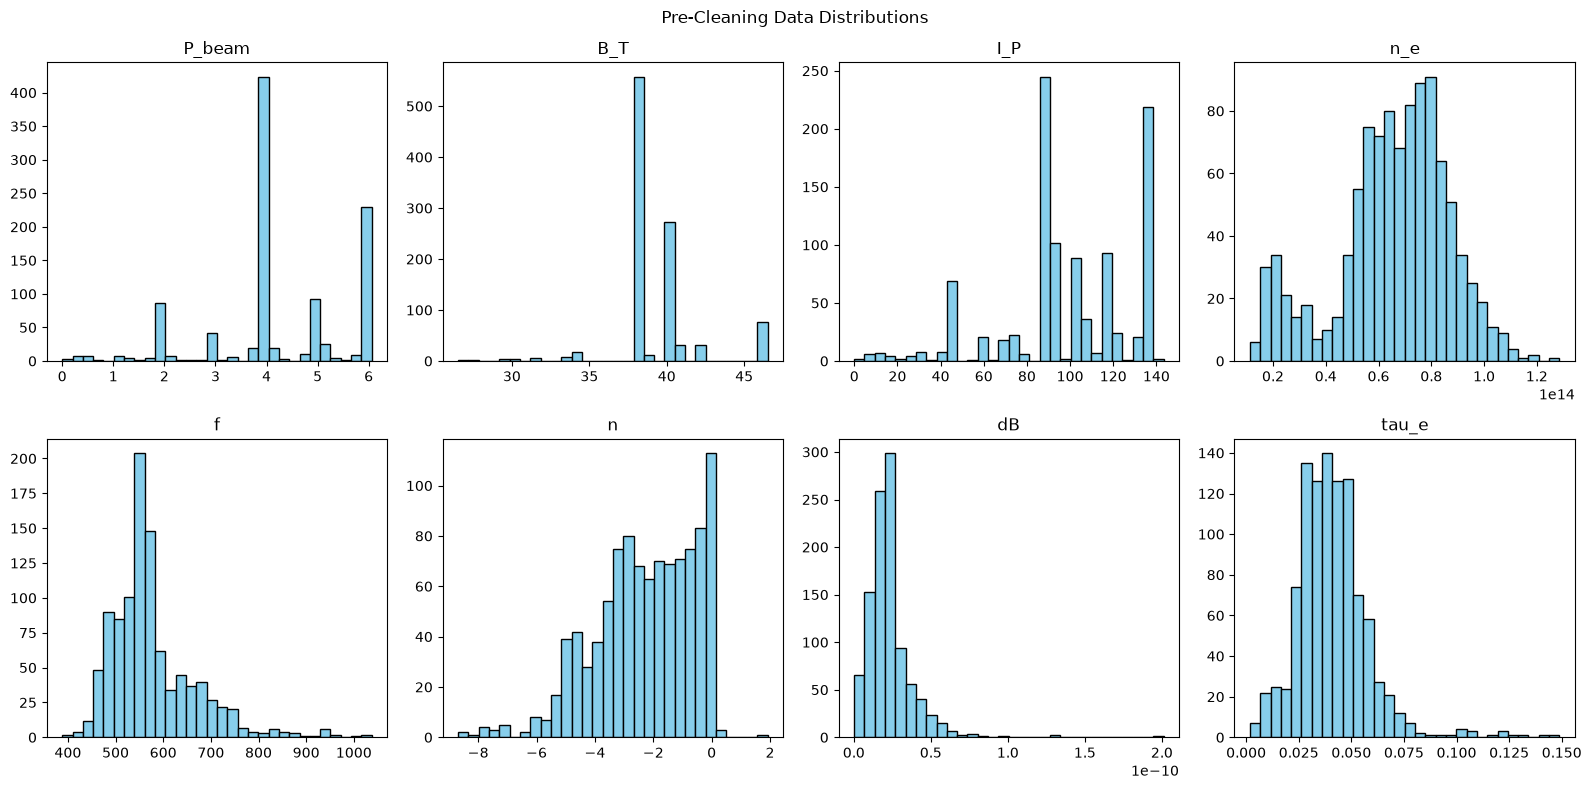

Size after removing extreme outliers (Z > 3): 961 rows

--- Training Stage 1: The 'Wave Predictor' ---
Wave Predictor R^2 Score: 0.550

--- Training Stage 2: The 'Confinement Predictor' ---
Confinement Predictor R^2 Score: 0.373

Physics Insights (Lasso Coefficients):
  P_beam: -0.00800
  B_T: -0.00248
  n_e: 0.00631
  f_norm: 0.00293
  n_norm: 0.00019
  dB2: 0.00240

--- Running Optimization Loop ---

Top 5 Operating Configurations for High Power (P_beam >= 6.0 MW):
 P_beam  B_T  I_P  n_e       f_norm         n_norm          dB2  predicted_tau_e
    6.0  0.3 1.30  5.0 6.457527e+07 -458065.642746 6.488414e-22         0.044963
    6.0  0.3 1.15  5.0 6.457527e+07 -458065.642746 6.488414e-22         0.044963
    6.0  0.3 0.70  5.0 6.457527e+07 -458065.642746 6.488414e-22         0.044963
    6.0  0.3 0.85  5.0 6.457527e+07 -458065.642746 6.488414e-22         0.044963
    6.0  0.3 1.00  5.0 6.457527e+07 -458065.642746 6.488414e-22         0.044963


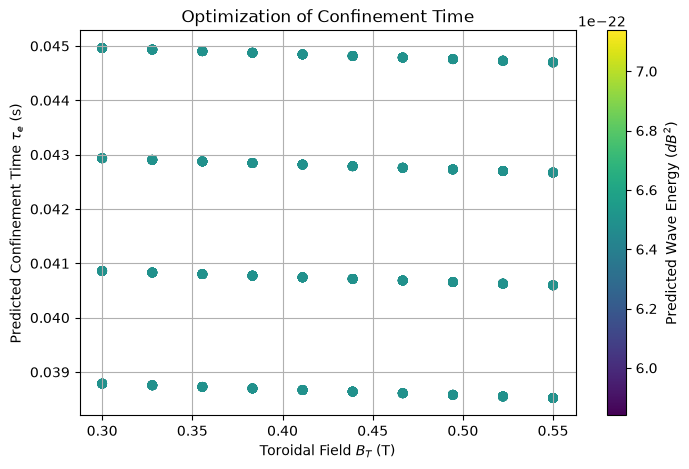

P_beam: -0.007997
B_T: -0.002481
I_P: -0.000000
n_e: 0.006309


In [ ]:


# =====================================================================
# STEP 0: DATA EXTRACTION, VISUALIZATION, AND CLEANING
# =====================================================================
def load_and_clean_data(filepath=None):
    """Loads plasma parameters from either a .csv file or an IDL .sav file.

    Plots distributions, removes negative confinement times, and drops
    outliers safely.
    """
    df = None

    if filepath and os.path.exists(filepath):
        if filepath.endswith(".csv"):
            df = pd.read_csv(filepath)

            # 1. Clean whitespace FIRST before mapping
            df.columns = df.columns.str.strip().str.replace("\ufeff", "")
            # Sum individual beam currents into a total
            if {"IBEAM_A", "IBEAM_B", "IBEAM_C"}.issubset(df.columns):
                df["I_BEAM"] = df["IBEAM_A"] + df["IBEAM_B"] + df["IBEAM_C"]

            # 2. Map exact CSV headers
            rename_dict = {
                "PBEAM_TOT": "P_beam",
                "BZXR": "B_T",
                "I_BEAM": "I_P",
                "NES": "n_e",
                "AVGMODEF": "f",
                "AVGMODEN": "n",
                "TOTPWR": "dB",
                "ETAU": "tau_e",
            }
            df = df.rename(columns=rename_dict)

        elif filepath.endswith(".sav"):
            data = readsav(filepath)
            df_mp = data.get("df_mp", data)
            try:
                df = pd.DataFrame({
                    "P_beam": (
                        df_mp["p_beam"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["p_beam"]
                    ),
                    "B_T": (
                        df_mp["b_t"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["b_t"]
                    ),
                    "I_P": (
                        df_mp["i_p"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["i_p"]
                    ),
                    "n_e": (
                        df_mp["n_e"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["n_e"]
                    ),
                    "f": (
                        df_mp["freq"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["freq"]
                    ),
                    "n": (
                        df_mp["mode_num"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["mode_num"]
                    ),
                    "dB": (
                        df_mp["db_amp"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["db_amp"]
                    ),
                    "tau_e": (
                        df_mp["tau_e"][0]
                        if isinstance(df_mp, np.recarray)
                        else df_mp["tau_e"]
                    ),
                })
            except Exception:
                df = pd.DataFrame({
                    "P_beam": data["p_beam"],
                    "B_T": data["b_t"],
                    "I_P": data["i_p"],
                    "n_e": data["n_e"],
                    "f": data["freq"],
                    "n": data["mode_num"],
                    "dB": data["db_amp"],
                    "tau_e": data["tau_e"],
                })

    if df is None or df.empty:
        raise ValueError(
            f"Failed to load data from path: {filepath}. Check if the file"
            " exists and is not empty."
        )

    print(f"Original dataset size: {len(df)} rows")

    # Ensure required columns are present
    required_cols = ["P_beam", "B_T", "I_P", "n_e", "f", "n", "dB", "tau_e"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns after mapping: {missing}. Found columns:"
            f" {list(df.columns)}"
        )

    # 1. Enforce Confinement Time Physics (tau_e > 0)
    df = df[df["tau_e"] > 0].copy()
    print(f"Size after enforcing tau_e > 0: {len(df)} rows")

    # 2. Visualize Data
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Pre-Cleaning Data Distributions")
    for ax, col in zip(axes.flatten(), required_cols):
        ax.hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

    # 3. Robust Outlier Removal (only compute Z-score on columns with variance)
    numeric_df = df[required_cols].copy()
    varying_cols = [col for col in required_cols if numeric_df[col].nunique() > 1]

    if varying_cols:
        z_scores = np.abs(stats.zscore(numeric_df[varying_cols]))
        valid_rows = (z_scores < 3).all(axis=1)
        df_clean = df[valid_rows].copy()
    else:
        df_clean = df.copy()

    print(f"Size after removing extreme outliers (Z > 3): {len(df_clean)} rows")

    if len(df_clean) == 0:
        raise ValueError(
            "Outlier removal resulted in 0 rows. Check dataset for invalid"
            " values."
        )

    return df_clean


# =====================================================================
# STEP 1 & 2: CAUSAL HIERARCHY & PHYSICS-INFORMED FEATURE ENGINEERING
# =====================================================================
# Keep only ONE engineer_features() definition in the notebook.
def engineer_features(df):
    df = df.copy()

    required = ["P_beam", "B_T", "I_P", "n_e", "f", "n", "dB", "tau_e"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for feature engineering: {missing}")

    df = df[df["n_e"] > 0].copy()
    df["v_A_proxy"] = df["B_T"] / np.sqrt(df["n_e"])
    df["f_norm"] = df["f"] / df["v_A_proxy"]
    df["n_norm"] = df["n"] / df["v_A_proxy"]
    df["dB2"] = df["dB"] ** 2

    X_control_cols = ["P_beam", "B_T", "I_P", "n_e"]
    Y_wave_cols = ["f_norm", "n_norm", "dB2"]
    Y_target_col = "tau_e"

    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df, X_control_cols, Y_wave_cols, Y_target_col


# =====================================================================
# STEP 3: THE TWO-STAGE SCIKIT-LEARN PIPELINE
# =====================================================================
def train_pipeline(df, X_control_cols, Y_wave_cols, Y_target_col):
    """Trains stage 1 and stage 2 surrogate models."""
    print("\n--- Training Stage 1: The 'Wave Predictor' ---")
    X1 = df[X_control_cols]
    Y1 = df[Y_wave_cols]

    X1_train, X1_test, Y1_train, Y1_test = train_test_split(
        X1, Y1, test_size=0.2, random_state=42
    )

    scaler_X1 = StandardScaler()
    X1_train_scaled = scaler_X1.fit_transform(X1_train)
    X1_test_scaled = scaler_X1.transform(X1_test)

    wave_model = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42)
    )
    wave_model.fit(X1_train_scaled, Y1_train)

    Y1_pred = wave_model.predict(X1_test_scaled)
    print(f"Wave Predictor R^2 Score: {r2_score(Y1_test, Y1_pred):.3f}")

    print("\n--- Training Stage 2: The 'Confinement Predictor' ---")
    X2 = pd.concat([df[X_control_cols], df[Y_wave_cols]], axis=1)
    Y2 = df[Y_target_col].values.ravel()

    X2_train, X2_test, Y2_train, Y2_test = train_test_split(
        X2, Y2, test_size=0.2, random_state=42
    )

    scaler_X2 = StandardScaler()
    X2_train_scaled = scaler_X2.fit_transform(X2_train)
    X2_test_scaled = scaler_X2.transform(X2_test)

    confinement_model = LassoCV(cv=5, random_state=42)
    confinement_model.fit(X2_train_scaled, Y2_train)

    Y2_pred = confinement_model.predict(X2_test_scaled)
    print(f"Confinement Predictor R^2 Score: {r2_score(Y2_test, Y2_pred):.3f}")

    print("\nPhysics Insights (Lasso Coefficients):")
    for feature, coef in zip(X2.columns, confinement_model.coef_):
        if abs(coef) > 1e-5:
            print(f"  {feature}: {coef:.5f}")

    return wave_model, confinement_model, scaler_X1, scaler_X2


# =====================================================================
# STEP 4: THE OPTIMIZATION LOOP
# =====================================================================
def optimize_operating_space(
    wave_model, confinement_model, scaler_X1, scaler_X2, X_control_cols
):
    """Generates operating grid to locate safe zones."""
    print("\n--- Running Optimization Loop ---")

    P_beam_grid = np.linspace(4.0, 7.0, 10)
    B_T_grid = np.linspace(0.3, 0.55, 10)
    I_P_grid = np.linspace(0.7, 1.3, 5)
    n_e_grid = np.linspace(2.0, 5.0, 5)

    grid = list(itertools.product(P_beam_grid, B_T_grid, I_P_grid, n_e_grid))
    df_grid = pd.DataFrame(grid, columns=X_control_cols)

    X1_sim_scaled = scaler_X1.transform(df_grid)
    predicted_waves = wave_model.predict(X1_sim_scaled)
    df_grid["f_norm"] = predicted_waves[:, 0]
    df_grid["n_norm"] = predicted_waves[:, 1]
    df_grid["dB2"] = predicted_waves[:, 2]

    X2_sim = df_grid[X_control_cols + ["f_norm", "n_norm", "dB2"]]
    X2_sim_scaled = scaler_X2.transform(X2_sim)
    df_grid["predicted_tau_e"] = confinement_model.predict(X2_sim_scaled)

    high_power_shots = df_grid[df_grid["P_beam"] >= 6.0]
    optimized_shots = high_power_shots.sort_values(
        by="predicted_tau_e", ascending=False
    )

    print("\nTop 5 Operating Configurations for High Power (P_beam >= 6.0 MW):")
    print(optimized_shots.head(5).to_string(index=False))

    plt.figure(figsize=(8, 5))
    plt.scatter(
        high_power_shots["B_T"],
        high_power_shots["predicted_tau_e"],
        c=high_power_shots["dB2"],
        cmap="viridis",
    )
    plt.colorbar(label="Predicted Wave Energy ($dB^2$)")
    plt.xlabel("Toroidal Field $B_T$ (T)")
    plt.ylabel("Predicted Confinement Time $\\tau_e$ (s)")
    plt.title("Optimization of Confinement Time")
    plt.grid(True)
    plt.show()

    for name, coef in zip(X_cols, confinement_model.coef_):
        print(f"{name}: {coef:.6f}")


# =====================================================================
# MAIN EXECUTION
# =====================================================================
if __name__ == "__main__":
    csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"

    df_raw = load_and_clean_data(filepath=csv_path)
    df_engineered, X_cols, Y_wave_cols, Y_target_col = engineer_features(
        df_raw
    )
    model1, model2, scale1, scale2 = train_pipeline(
        df_engineered, X_cols, Y_wave_cols, Y_target_col
    )
    optimize_operating_space(model1, model2, scale1, scale2, X_cols)

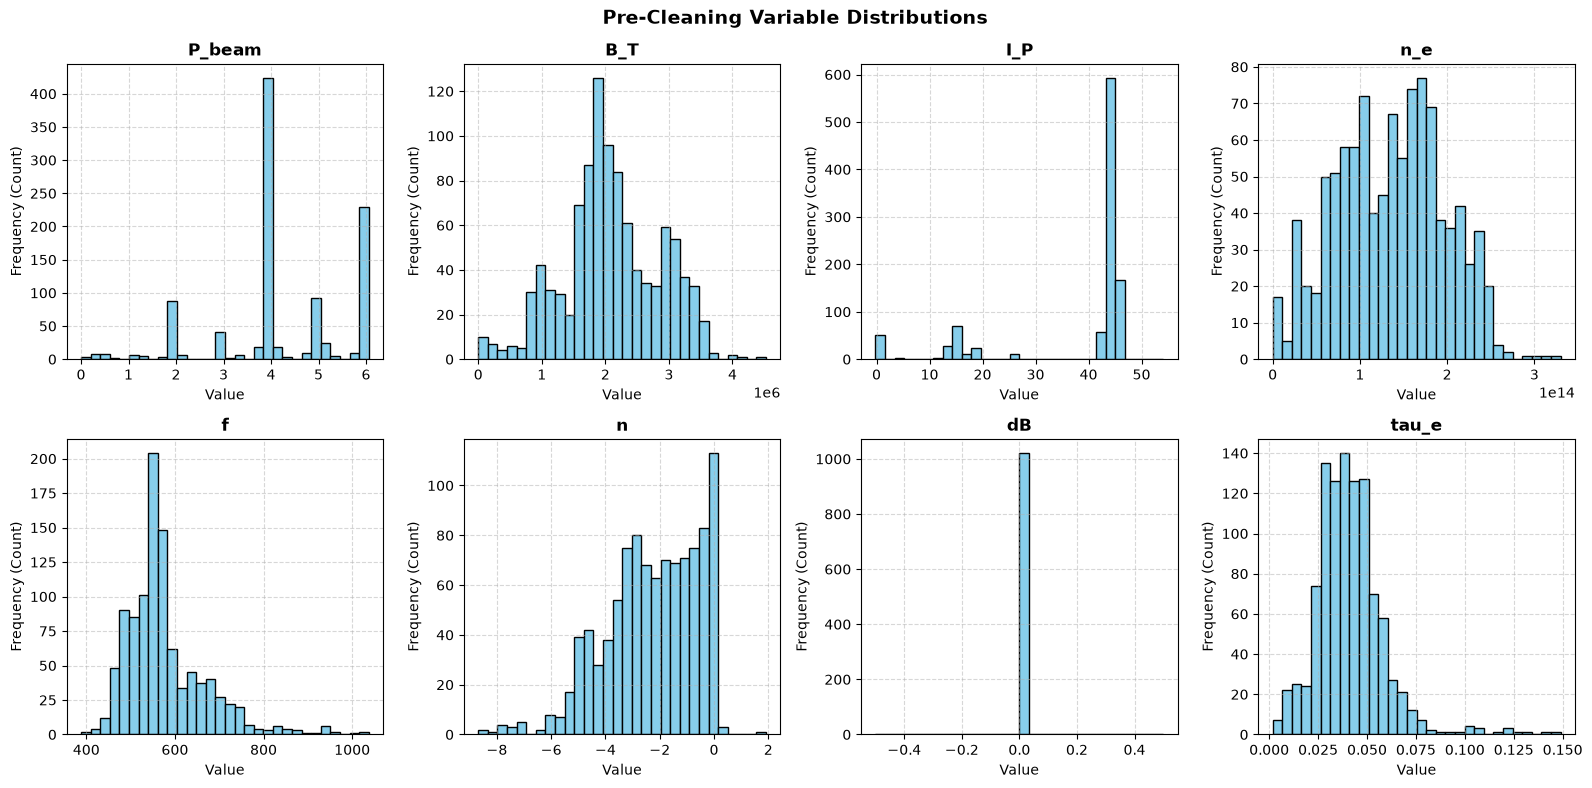

Dataset successfully prepared: 977 clean rows.
Stage 1 (Wave Predictor) R² Score: 0.730
Stage 2 (Confinement Predictor) R² Score: 0.249

--- Running Optimization Loop ---

Top 5 High-Power Configurations (P_beam >= 6.0 MW):
 P_beam  B_T  I_P  n_e      f_norm    n_norm  dB2  predicted_tau_e
    7.0  0.3  0.7 5.00 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 4.25 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 3.50 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 2.75 4929.741798 -7.993748  0.0         0.059874
    7.0  0.3  0.7 2.00 4929.741798 -7.993748  0.0         0.059874


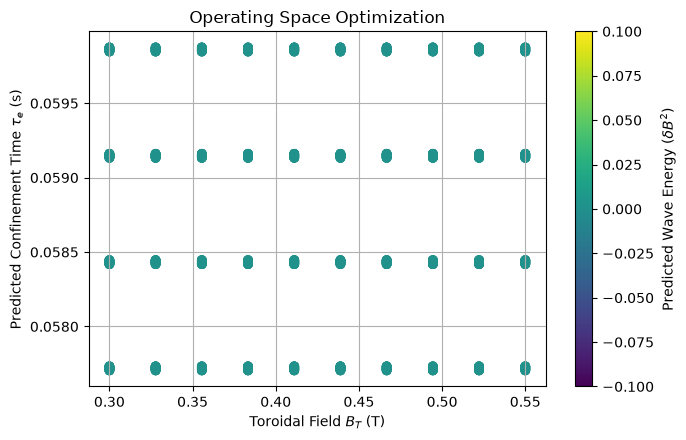

P_beam: 0.002782
B_T: -0.014412
I_P: -0.000585
n_e: 0.011694
f_norm: -0.002201
n_norm: 0.000261
dB2: 0.000000


In [ ]:

# =====================================================================
# 1. USER CONFIGURATION (MAP YOUR VARIABLES HERE)
# =====================================================================
CSV_PATH = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"

# Map YOUR_CSV_HEADER : PIPELINE_VARIABLE
COLUMN_MAPPING = {
    "PBEAM_TOT": "P_beam",  # Beam Power (MW)
    "BPTE": "B_T",  # Toroidal Field (T)
    "IBEAM_A": "I_P",  # Plasma Current (MA)
    "NEUTT": "n_e",  # Electron Density
    "AVGMODEF": "f",  # Mode Frequency
    "AVGMODEN": "n",  # Mode Number
    "DIFB": "dB",  # Fluctuation Amplitude
    "ETAU": "tau_e",  # Confinement Time (s)
}

# Causal Hierarchy
X_CONTROL_COLS = ["P_beam", "B_T", "I_P", "n_e"]
Y_WAVE_COLS = ["f_norm", "n_norm", "dB2"]
Y_TARGET_COL = "tau_e"


# =====================================================================
# 2. VISUALIZATION & DATA CLEANING
# =====================================================================
def plot_distributions(df, columns, title="Pre-Cleaning Data Distributions"):
    """Plots frequency (count) over value for each physical variable."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, col in zip(axes.flatten(), columns):
        if col in df.columns:
            ax.hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
            ax.set_title(col, fontsize=12, fontweight="bold")
            ax.set_xlabel("Value")
            ax.set_ylabel("Frequency (Count)")
            ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


def load_and_prep_data(filepath, col_map):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found at: {filepath}")

    # Load and clean header strings
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "")
    df = df.rename(columns=col_map)

    # Validate mapped columns
    required = list(col_map.values())
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing mapped columns: {missing}. Available headers in CSV:"
            f" {list(df.columns)}"
        )

    # Filter physical sanity bounds (tau_e > 0 and n_e > 0)
    df = df[(df["tau_e"] > 0) & (df["n_e"] > 0)].copy()

    # --- Plot raw variable distributions before outlier filtering ---
    plot_distributions(df, required, title="Pre-Cleaning Variable Distributions")

    # Outlier removal via Z-score
    var_cols = [c for c in required if df[c].nunique() > 1]
    if var_cols:
        z_scores = np.abs(stats.zscore(df[var_cols]))
        df = df[(z_scores < 3).all(axis=1)].copy()

    print(f"Dataset successfully prepared: {len(df)} clean rows.")
    return df





# ...existing code...
# =====================================================================
# 4. TWO-STAGE MODEL PIPELINE
# =====================================================================
def train_pipeline(df, X_control_cols, Y_wave_cols, Y_target_col):
    # Stage 1: control knobs -> wave dynamics
    X1 = df[X_control_cols]
    Y1 = df[Y_wave_cols]
    X1_tr, X1_te, Y1_tr, Y1_te = train_test_split(
        X1, Y1, test_size=0.2, random_state=42
    )

    scaler_X1 = StandardScaler()
    X1_tr_s = scaler_X1.fit_transform(X1_tr)
    X1_te_s = scaler_X1.transform(X1_te)

    wave_model = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42)
    )
    wave_model.fit(X1_tr_s, Y1_tr)

    print(
        "Stage 1 (Wave Predictor) R² Score: "
        f"{r2_score(Y1_te, wave_model.predict(X1_te_s)):.3f}"
    )

    # Stage 2: knobs + waves -> confinement time
    X2 = pd.concat([df[X_control_cols], df[Y_wave_cols]], axis=1)
    Y2 = df[Y_target_col].values.ravel()
    X2_tr, X2_te, Y2_tr, Y2_te = train_test_split(
        X2, Y2, test_size=0.2, random_state=42
    )

    scaler_X2 = StandardScaler()
    X2_tr_s = scaler_X2.fit_transform(X2_tr)
    X2_te_s = scaler_X2.transform(X2_te)

    confinement_model = LassoCV(cv=5, random_state=42)
    confinement_model.fit(X2_tr_s, Y2_tr)

    print(
        "Stage 2 (Confinement Predictor) R² Score: "
        f"{r2_score(Y2_te, confinement_model.predict(X2_te_s)):.3f}"
    )

    return wave_model, confinement_model, scaler_X1, scaler_X2


# =====================================================================
# 5. OPTIMIZATION GRID SEARCH
# =====================================================================
def optimize_operating_space(
    wave_model, confinement_model, scaler_X1, scaler_X2,
    X_control_cols, Y_wave_cols
):
    """Generates operating grid to locate high-confinement configurations."""
    print("\n--- Running Optimization Loop ---")

    P_beam_grid = np.linspace(4.0, 7.0, 10)
    B_T_grid = np.linspace(0.3, 0.55, 10)
    I_P_grid = np.linspace(0.7, 1.3, 5)
    n_e_grid = np.linspace(2.0, 5.0, 5)

    grid = list(itertools.product(P_beam_grid, B_T_grid, I_P_grid, n_e_grid))
    df_grid = pd.DataFrame(grid, columns=X_control_cols)

    waves_pred = wave_model.predict(scaler_X1.transform(df_grid))
    for i, col in enumerate(Y_wave_cols):
        df_grid[col] = waves_pred[:, i]

    X2_sim = df_grid[X_control_cols + Y_wave_cols]
    df_grid["predicted_tau_e"] = confinement_model.predict(
        scaler_X2.transform(X2_sim)
    )

    high_power = df_grid[df_grid["P_beam"] >= 6.0].sort_values(
        by="predicted_tau_e", ascending=False
    )

    print("\nTop 5 High-Power Configurations (P_beam >= 6.0 MW):")
    print(high_power.head(5).to_string(index=False))

    plt.figure(figsize=(7, 4.5))
    plt.scatter(
        high_power["B_T"],
        high_power["predicted_tau_e"],
        c=high_power["dB2"],
        cmap="viridis",
    )
    plt.colorbar(label=r"Predicted Wave Energy ($\delta B^2$)")
    plt.xlabel(r"Toroidal Field $B_T$ (T)")
    plt.ylabel(r"Predicted Confinement Time $\tau_e$ (s)")
    plt.title("Operating Space Optimization")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    feature_names = X_control_cols + Y_wave_cols
    for name, coef in zip(feature_names, confinement_model.coef_):
        print(f"{name}: {coef:.6f}")


# =====================================================================
# MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    df_clean = load_and_prep_data(CSV_PATH, COLUMN_MAPPING)
    df_feat, X_cols, Y_wave_cols, Y_target_col = engineer_features(df_clean)
    m1, m2, s1, s2 = train_pipeline(
        df_feat, X_cols, Y_wave_cols, Y_target_col
    )
    optimize_operating_space(m1, m2, s1, s2, X_cols, Y_wave_cols)

# Variable Distribution and visualization

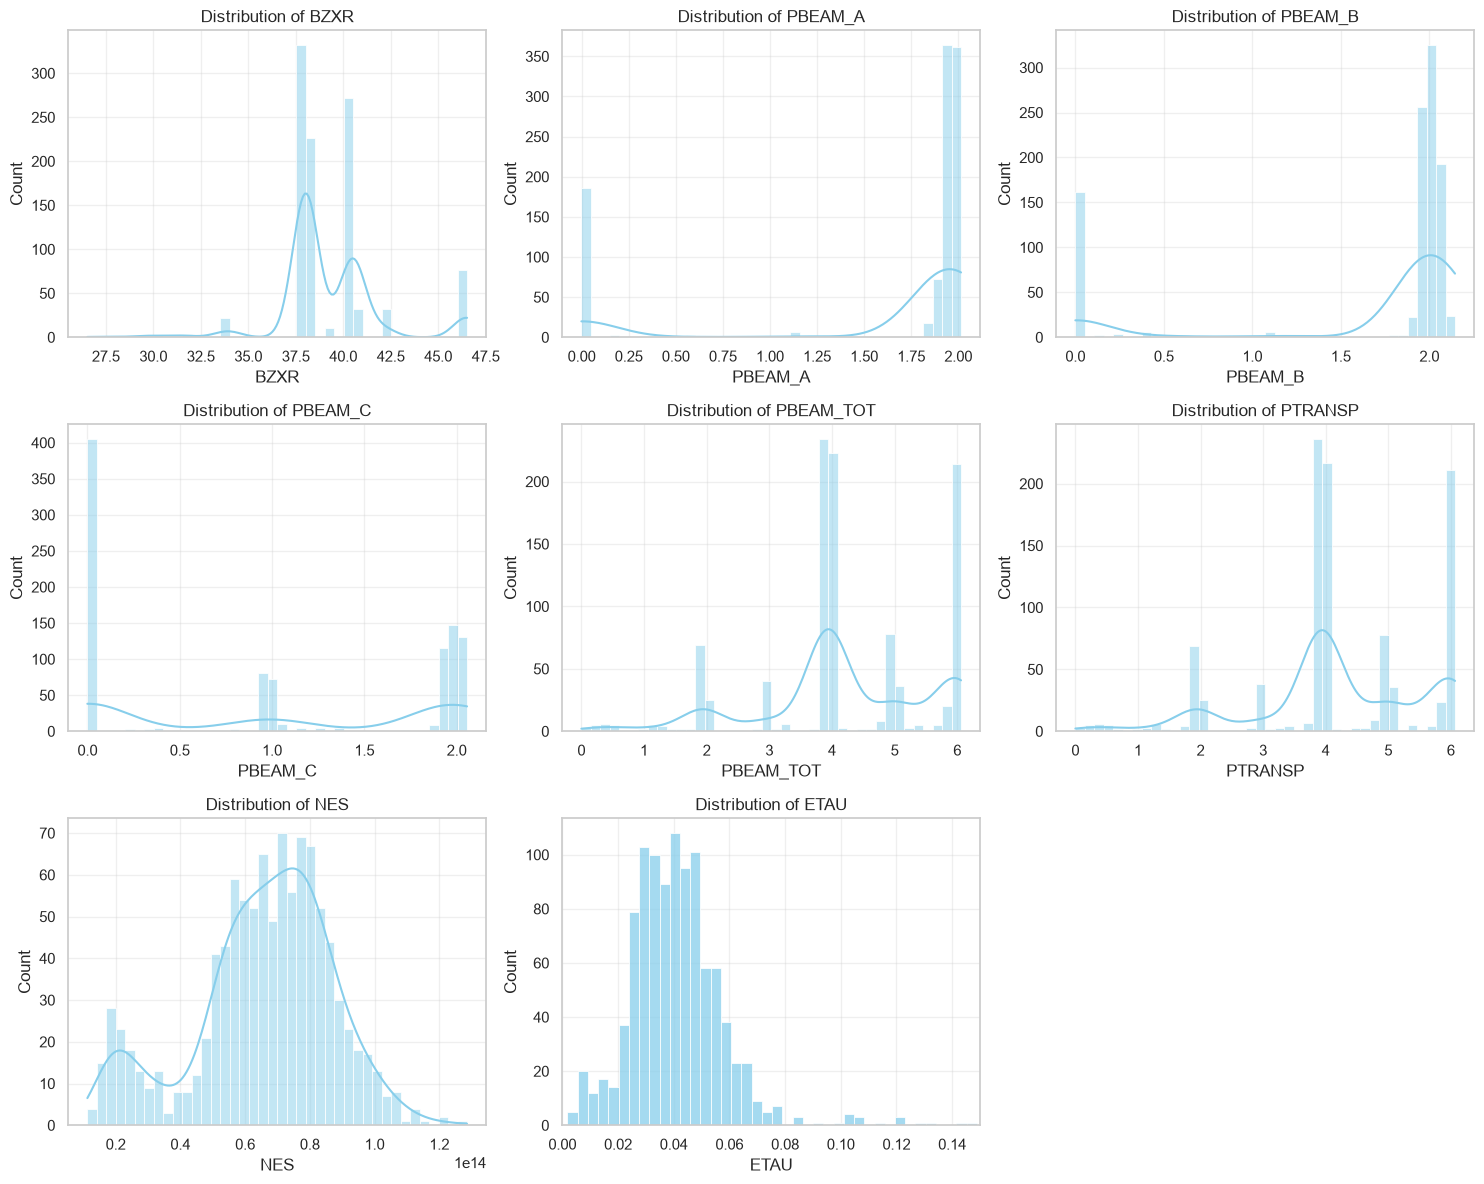

In [ ]:
# ...existing code...
csv_path = r"/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

def plot_variables(df, vars_to_plot=None, n_cols=3, target_names=None, target_clip=(0.0, 0.150)):
    """
    Plot distributions for selected variables.
      - vars_to_plot: list of column names to plot or None -> all numeric columns
      - n_cols: number of subplot columns
      - target_names: list of columns to treat with clipping (e.g. ['ETAU','tau_e'])
      - target_clip: (min, max) for clipping target histograms
    """
    if vars_to_plot is None:
        vars_to_plot = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        missing = [c for c in vars_to_plot if c not in df.columns]
        if missing:
            raise KeyError(f"Columns not found in dataframe: {missing}")

    n_rows = math.ceil(len(vars_to_plot) / n_cols)
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = np.asarray(axes).flatten()

    for i, col in enumerate(vars_to_plot):
        ax = axes[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            is_target = (target_names is not None and col in target_names) or (col.lower() in ("etau", "tau_e"))
            if is_target:
                vals = df[col].dropna().clip(lower=target_clip[0], upper=target_clip[1])
                sns.histplot(vals, bins=40, kde=False, color="skyblue", ax=ax)
                ax.set_xlim(target_clip)
            else:
                sns.histplot(df[col].dropna(), bins=40, kde=True, color="skyblue", ax=ax)
            ax.set_title(f"Distribution of {col}")
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
        else:
            if df[col].nunique() <= 50:
                sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="muted", ax=ax)
                ax.set_title(f"Value counts for {col}")
            else:
                ax.text(0.5, 0.5, f"Non-numeric / >50 unique values ({df[col].nunique()})", ha="center", va="center")
                ax.set_title(col)
                ax.axis("off")
        ax.grid(alpha=0.3)

    # remove unused axes
    for j in range(len(vars_to_plot), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# -------------------------
# Choose variables to plot:
# - Set variables_to_plot = None to plot all numeric columns
# - Or provide an explicit list, e.g. ['ETAU','TE','PBEAM_TOT']
variables_to_plot = ['BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PTRANSP', 'NES', 'ETAU']

plot_variables(df, vars_to_plot=variables_to_plot, n_cols=3, target_names=['ETAU'])
# ...existing code...

In [ ]:
# ...existing code...
csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

def norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

# find ETAU / tau_e column (robust)
target_col = None
for alt in ("etau", "taue", "tau_e", "eta_u", "etau"):
    match = next((c for c in df.columns if norm(c) == norm(alt)), None)
    if match is not None:
        target_col = match
        break
if target_col is None:
    raise ValueError("No ETAU / tau_e column found in the dataframe.")

def plot_target_vs_vars(df, target_col, x_vars=None, max_vars=47, cols=7, figsize_per_col=(4,3)):
    """
    Plots scatter of target_col vs each variable in x_vars.
    - x_vars: list of column names to plot (defaults to first numeric cols excluding target up to max_vars)
    - max_vars: fallback limit if x_vars is None
    - cols: number of subplot columns
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidates = [c for c in numeric_cols if c != target_col]

    if x_vars is None:
        x_vars = candidates[:max_vars]
    else:
        missing = [c for c in x_vars if c not in df.columns]
        if missing:
            raise KeyError(f"Columns not found in dataframe: {missing}")
        # ensure we only plot numeric / available ones
        x_vars = [c for c in x_vars if pd.api.types.is_numeric_dtype(df[c]) and c != target_col]
        if not x_vars:
            raise ValueError("No valid numeric x variables to plot after filtering.")

    n_plots = len(x_vars)
    rows = math.ceil(n_plots / cols)
    fig_w = cols * figsize_per_col[0]
    fig_h = rows * figsize_per_col[1]
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    axes = np.asarray(axes).ravel()

    plot_idx = 0
    for ax, xcol in zip(axes, x_vars):
        sub = df[[xcol, target_col]].dropna().copy()
        sub = sub[np.isfinite(sub[xcol]) & np.isfinite(sub[target_col])]
        if sub.empty:
            ax.axis("off")
        else:
            ax.scatter(sub[xcol], sub[target_col], s=12, alpha=0.7, color="tab:blue", edgecolors="none")
            ax.set_xlabel(xcol, fontsize=8)
            ax.set_ylabel(target_col, fontsize=8)
            ax.set_title(f"{target_col} vs {xcol}", fontsize=8)
            ax.grid(alpha=0.25)
        plot_idx += 1

    # hide any remaining unused axes
    for j in range(plot_idx, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{target_col} vs selected numeric variables", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Usage:
#  - Provide a list of variables to plot, e.g.:
#    my_vars = ['BZXR','PBEAM_A','PBEAM_B'] 
#  - Or set my_vars = None to use the first 47 numeric variables (excluding target)
my_vars = ['BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PTRANSP', 'NES', 'ETAU']

plot_target_vs_vars(df, target_col, x_vars=my_vars, max_vars=47, cols=7)
# ...existing code...

KeyError: "Columns not found in dataframe: ['BZXR', 'PTRANSP', 'NES']"

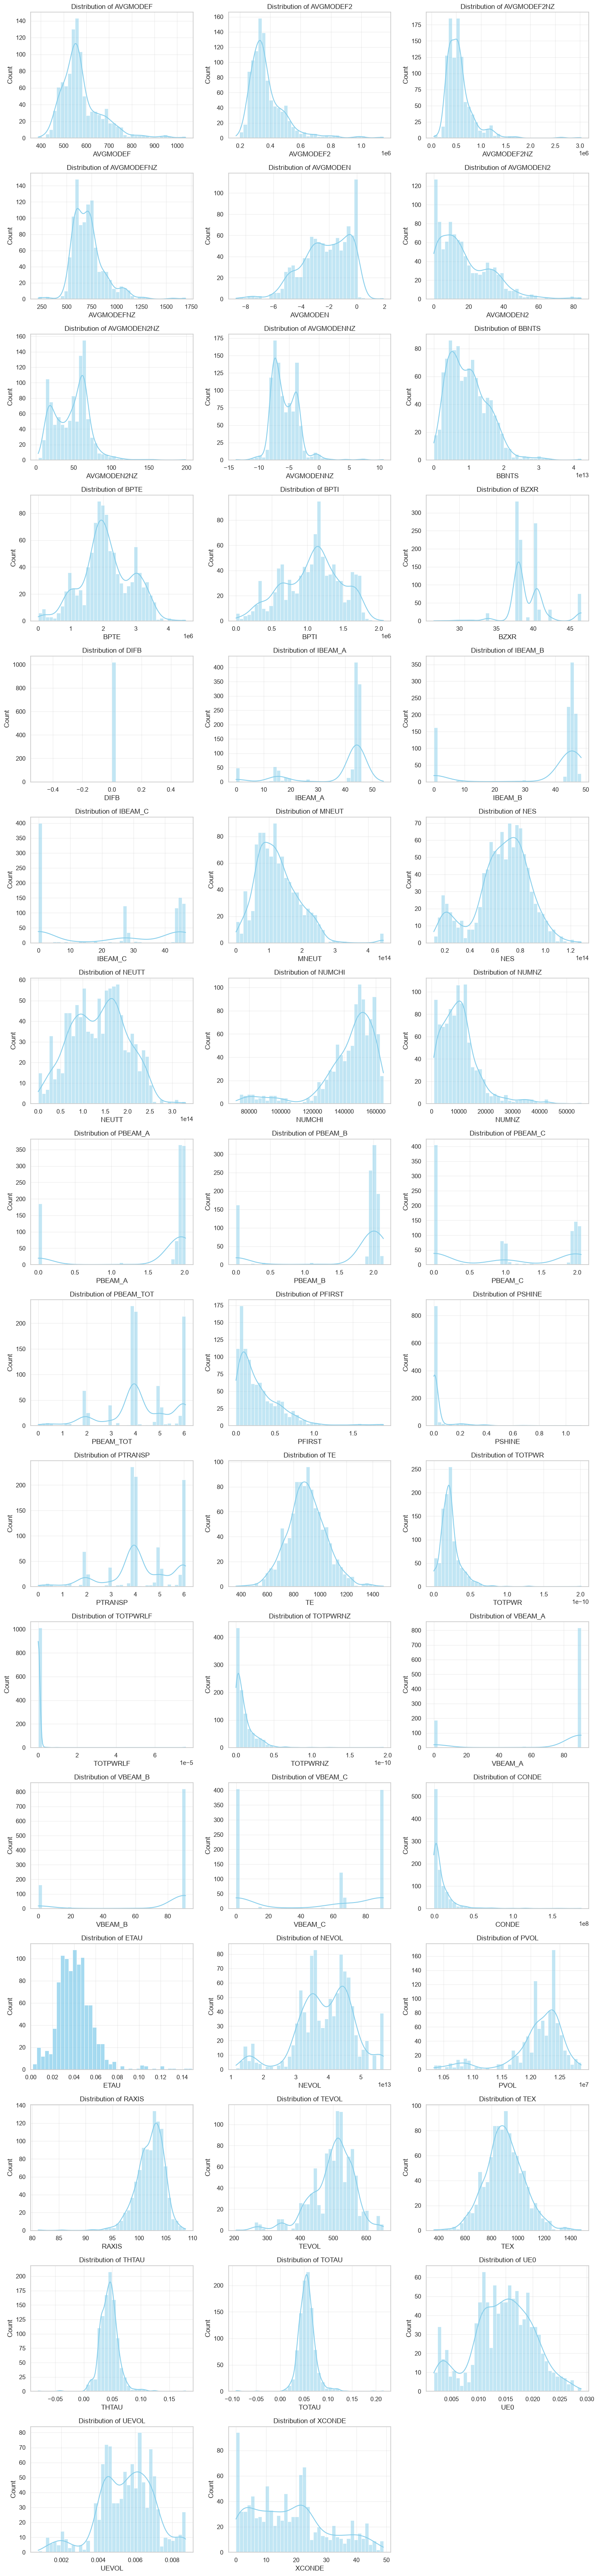

In [ ]:


csv_path = (
    r"/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
)
if not os.path.exists(csv_path):
  raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

# Find ETAU (case-insensitive) or tau_e
etau_col = next((c for c in df.columns if c.lower() in ("etau", "tau_e")), None)
if etau_col is None:
  raise KeyError("No ETAU / tau_e column found in CSV")

# --- Grid Configuration ---
n_cols = 3  # Adjust the number of columns in the grid as needed
n_rows = math.ceil(len(df.columns) / n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy indexing

# --- Plotting Loop ---
for i, col in enumerate(df.columns):
  ax = axes[i]

  if pd.api.types.is_numeric_dtype(df[col]):
    if col.lower() in ("etau", "tau_e"):
      vals = df[col].dropna().clip(lower=0.0, upper=0.150)
      sns.histplot(vals, bins=40, kde=False, color="skyblue", ax=ax)
      ax.set_title(f"Distribution of {col}")
      ax.set_xlim(0.000, 0.150)
    else:
      sns.histplot(df[col].dropna(), bins=40, kde=True, color="skyblue", ax=ax)
      ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

  else:
    if df[col].nunique() <= 50:
      sns.countplot(
          y=col,
          data=df,
          order=df[col].value_counts().index,
          palette="muted",
          ax=ax,
          hue=col,
          legend=False,
      )
      ax.set_title(f"Value counts for {col}")
    else:
      ax.text(
          0.5,
          0.5,
          f"Non-numeric / >50 unique values ({df[col].nunique()})",
          ha="center",
          va="center",
      )
      ax.set_title(col)
      ax.axis("off")

  ax.grid(alpha=0.3)

# Hide any empty unused subplot slots
for j in range(len(df.columns), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

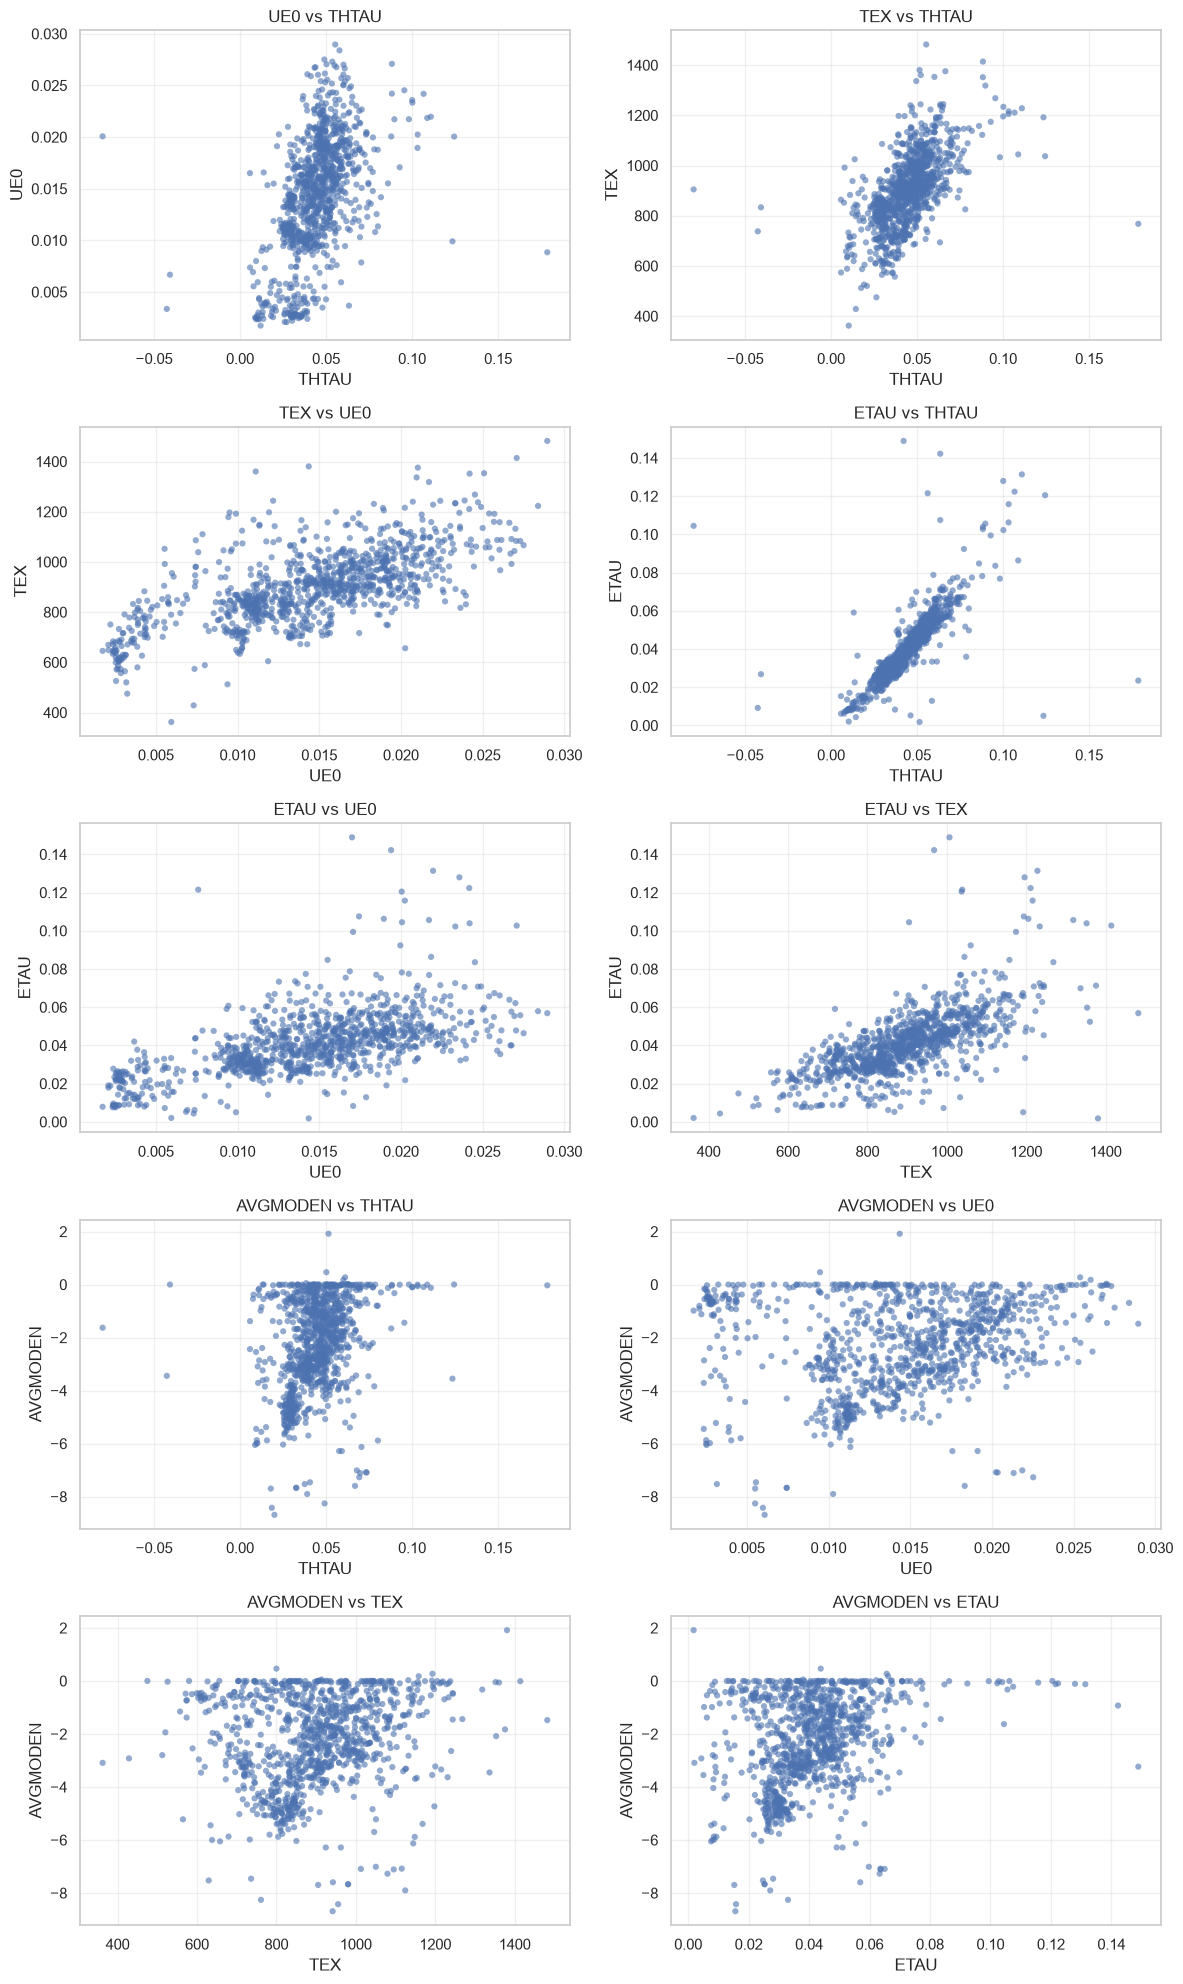

In [ ]:



csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
df_base = pd.read_csv(csv_path)
df_base.columns = df_base.columns.str.strip().str.replace("\ufeff", "")

# no ETAU filter applied here
df_plot = df_base.copy()

# preferred variables (case-insensitive matching)
preferred = ["THTAU", "TE", "UE0", "TEX", "ETAU", 'AVGMODEN']

def norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

colmap = {norm(c): c for c in df_plot.columns}
vars_found = [colmap[norm(v)] for v in preferred if norm(v) in colmap]

# fallback to numeric columns if fewer than 5 found
if len(vars_found) < 5:
    vars_found = df_plot.select_dtypes(include=[np.number]).columns.tolist()

if len(vars_found) < 2:
    raise ValueError("Not enough numeric columns to plot scatter pairs.")

# build lower-triangle pairs (y vs x) and take first 10
pairs = []
for i in range(len(vars_found)):
    for j in range(i):
        pairs.append((vars_found[i], vars_found[j]))
pairs = pairs[:10]

# plot grid (5x2)
n = len(pairs)
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for ax, (ycol, xcol) in zip(axes, pairs):
    sub = df_plot[[xcol, ycol]].dropna()
    ax.scatter(sub[xcol], sub[ycol], s=20, alpha=0.6, edgecolor='none')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} vs {xcol}")
    ax.grid(alpha=0.3)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

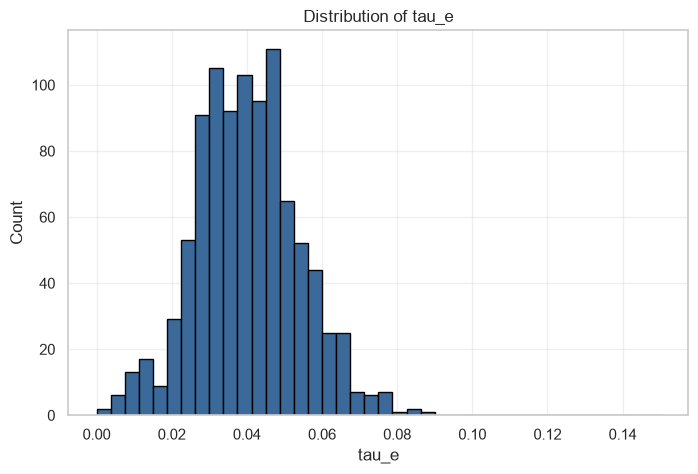

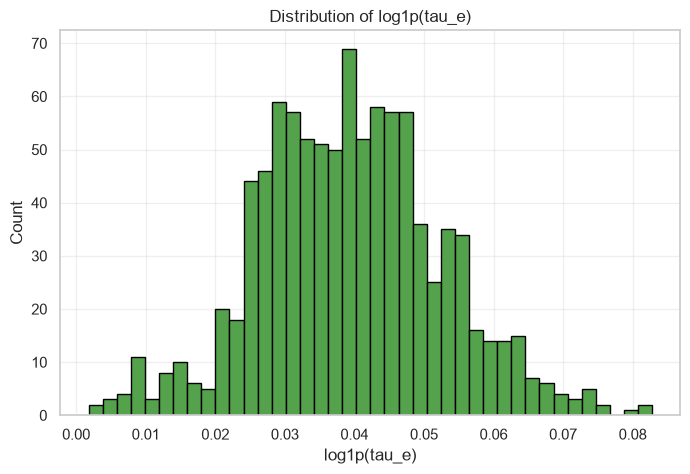

Skewness of tau_e: 0.158
Skewness of log1p(tau_e): 0.115


In [ ]:
# Build the dataframe only from notebook-defined objects
if "df_raw" not in globals():
    df_raw = load_and_clean_data(filepath=filepath)

def inspect_local_target(frame):
    target_candidates = ("tau_e", "ETAU", "etau")
    target = next((c for c in target_candidates if c in frame.columns), None)
    if target is None:
        raise ValueError("No valid target column found in the local dataframe.")

    work = frame.select_dtypes(include=[np.number]).copy()
    corr = work.corr(numeric_only=True)

 

    plt.figure(figsize=(8, 5))
    plt.hist(frame[target].dropna(), bins=40, range = (0, 0.15), color="#3B699A", edgecolor="black")
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

    log_target = np.log1p(frame[target].clip(lower=0))
    plt.figure(figsize=(8, 5))
    plt.hist(log_target.dropna(), bins=40, color="#54A24B", edgecolor="black")
    plt.title(f"Distribution of log1p({target})")
    plt.xlabel(f"log1p({target})")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Skewness of {target}: {frame[target].skew():.3f}")
    print(f"Skewness of log1p({target}): {log_target.skew():.3f}")

    return target, corr

target_col, corr_matrix = inspect_local_target(df_raw)

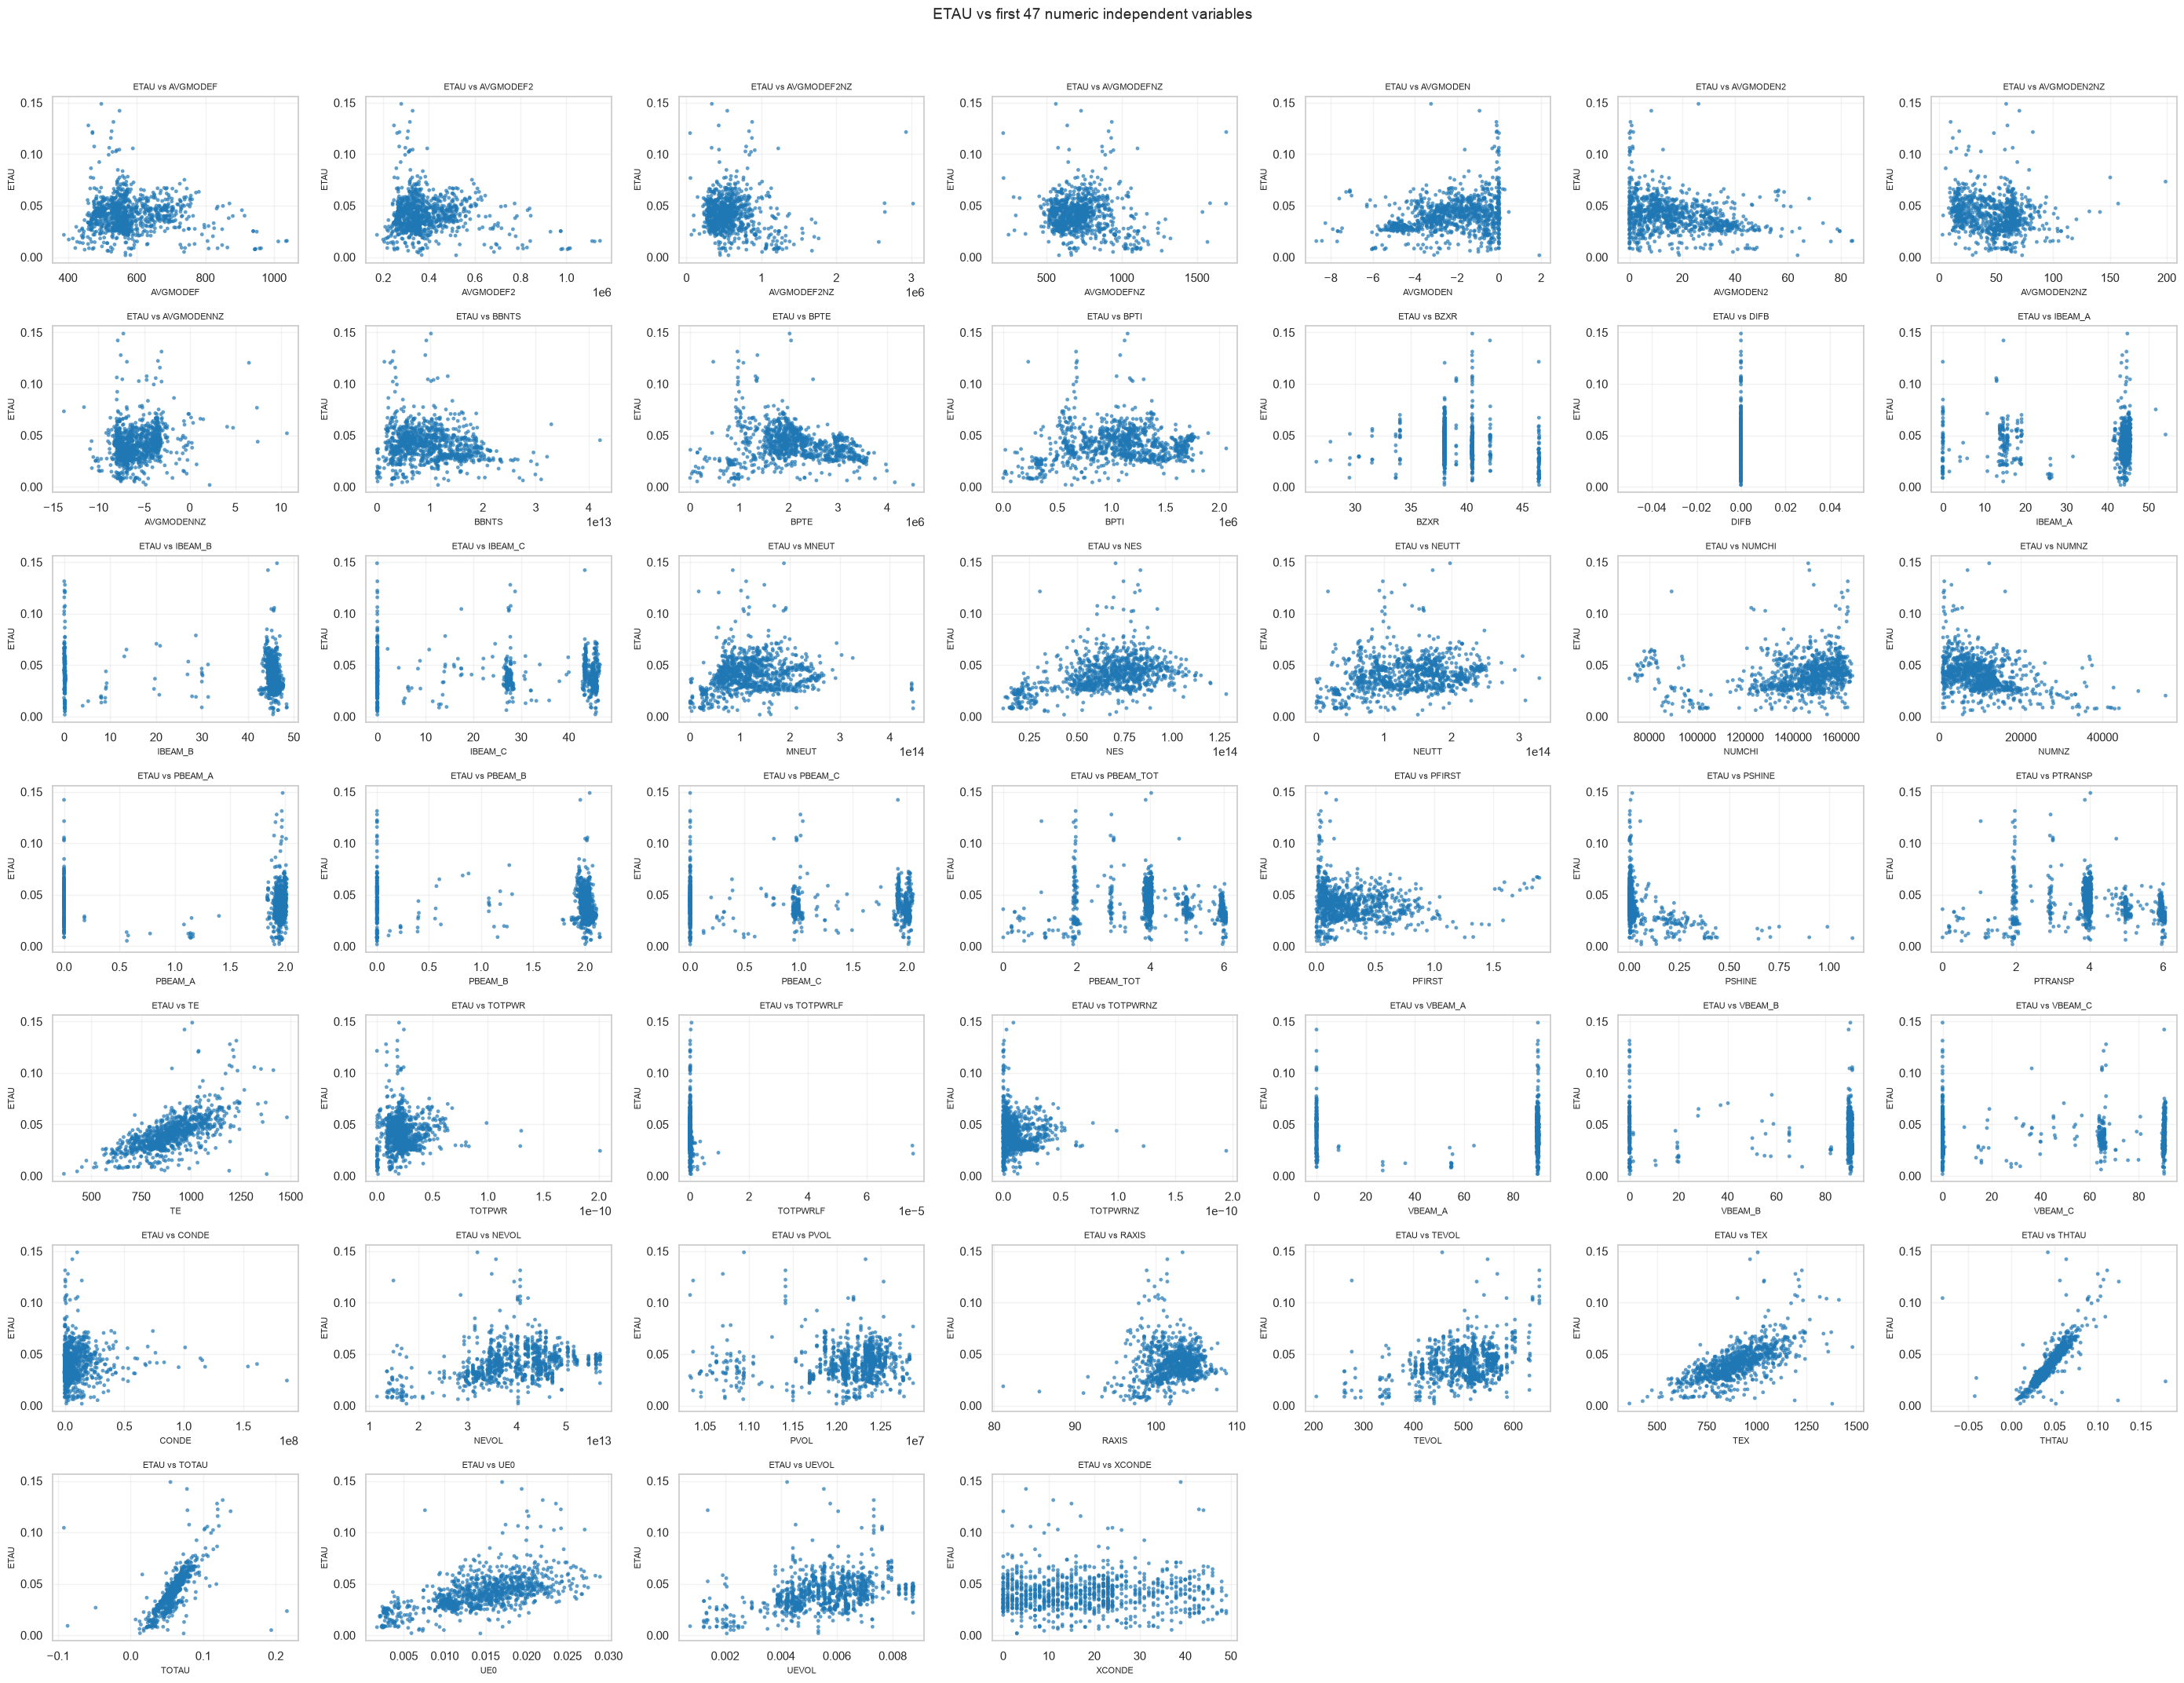

Generated 46 scatterplots for target 'ETAU'.
X variables used: ['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN', 'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI', 'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES', 'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF', 'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'CONDE', 'NEVOL', 'PVOL', 'RAXIS', 'TEVOL', 'TEX', 'THTAU', 'TOTAU', 'UE0', 'UEVOL', 'XCONDE']


In [ ]:


csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

def norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

# find ETAU / tau_e column
target_col = None
for alt in ("etau", "taue", "tau_e", "eta_u", "etau"):
    alt_norm = norm(alt)
    match = next((c for c in df.columns if norm(c) == alt_norm), None)
    if match is not None:
        target_col = match
        break

if target_col is None:
    raise ValueError("No ETAU / tau_e column found in the dataframe.")

# keep only numeric independent variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
x_vars = [c for c in numeric_cols if c != target_col]

# keep only first 47 variables
x_vars = x_vars[:47]

if len(x_vars) == 0:
    raise ValueError("No numeric independent variables available for scatter plots.")

# optionally keep only positive ETAU values
y_vals = df[target_col].dropna()
if y_vals.empty:
    raise ValueError(f"Target column '{target_col}' has no valid values.")

# build a 7x7 grid for 49 slots (47 scatterplots + 2 empty)
n_plots = len(x_vars)
cols = 7
rows = math.ceil((n_plots + 2) / cols)  # leaves 2 empty slots if 47 plots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = np.asarray(axes).ravel()

plot_idx = 0
for ax, xcol in zip(axes, x_vars):
    sub = df[[xcol, target_col]].dropna().copy()

    # optional: drop non-finite values
    sub = sub[np.isfinite(sub[xcol]) & np.isfinite(sub[target_col])]

    if sub.empty:
        ax.axis("off")
        continue

    ax.scatter(sub[xcol], sub[target_col], s=12, alpha=0.7, color="tab:blue", edgecolors="none")
    ax.set_xlabel(xcol, fontsize=8)
    ax.set_ylabel(target_col, fontsize=8)
    ax.set_title(f"{target_col} vs {xcol}", fontsize=8)
    ax.grid(alpha=0.25)

    plot_idx += 1

# hide any remaining unused axes
for j in range(plot_idx, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"{target_col} vs first 47 numeric independent variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Generated {len(x_vars)} scatterplots for target '{target_col}'.")
print("X variables used:", x_vars)

# Spearman Matrices


Mapped columns for correlation: {'THTAU': 'THTAU', 'TOTAU': 'TOTAU', 'TE': 'BPTE', 'TEX': 'TEX', 'UE0': 'UE0', 'TOTPWR': 'TOTPWR', 'BPTI': 'BPTI', 'PTRANSP': 'PTRANSP', 'AVGMODEN': 'AVGMODEN', 'tau_e': 'ETAU'}


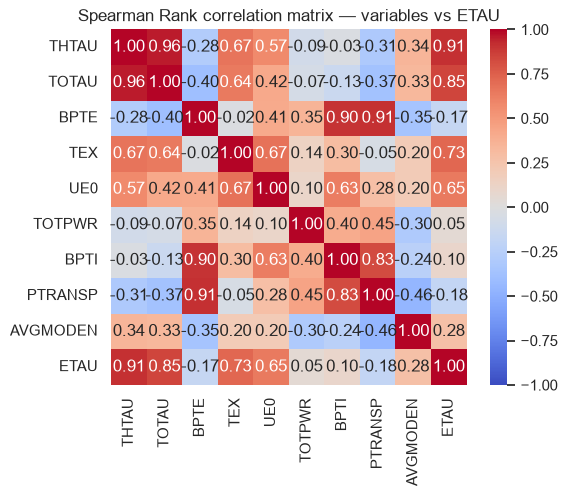


Correlation with ETAU
THTAU       0.909610
TOTAU       0.848422
TEX         0.725674
UE0         0.645220
AVGMODEN    0.277154
BPTI        0.097301
TOTPWR      0.049792
BPTE       -0.165067
PTRANSP    -0.181669


In [ ]:
# ...existing code...


csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)
frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")

def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())

col_map = {norm(c): c for c in frame.columns}

candidates = {
   "THTAU" : ["THTAU"],
   "TOTAU" : ["TOTAU"],
   "TE" : ["TE"],  
   "TEX" : ["TEX"],    
   "UE0" : ["UE0"],
   "TOTPWR" : ["TOTPWR"],
   "BPTI" : ["BPTI"],
   "PTRANSP" : ["PTRANSP"],
   "AVGMODEN" : ["AVGMODEN"]
}



# ...existing code...
found = {}
for key, toks in candidates.items():
    for t in toks:
        t_norm = norm(t)
        matches = [v for k, v in col_map.items() if t_norm in k]
        if matches:
            found[key] = matches[0]
            break

if "tau_e" not in found:
    for alt in ("taue", "etau", "tau_e", "eta_u", "etaU"):
        alt_norm = norm(alt)
        if alt_norm in col_map:
            found["tau_e"] = col_map[alt_norm]
            break
# ...existing code...

print("Mapped columns for correlation:", found)

use_cols = [v for k,v in found.items() if k in ("THTAU","TOTAU","TE","TEX", "UE0", "TOTPWR", "BPTI", "PTRANSP", "AVGMODEN", "tau_e")]
df_corr = frame[use_cols].copy().select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows after dropna for selected columns.")

corr = df_corr.corr(method="spearman")

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Spearman Rank correlation matrix — variables vs ETAU")
plt.tight_layout()
plt.show()

# print sorted correlations with tau_e
target_col = found.get("tau_e")
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print("\nCorrelation with", target_col)
    print(corr_with_target.to_string())
else:
    print("Target column not found in computed correlation matrix.")
# ...existing code...




Computing Spearman matrix for all 47 numeric variables...


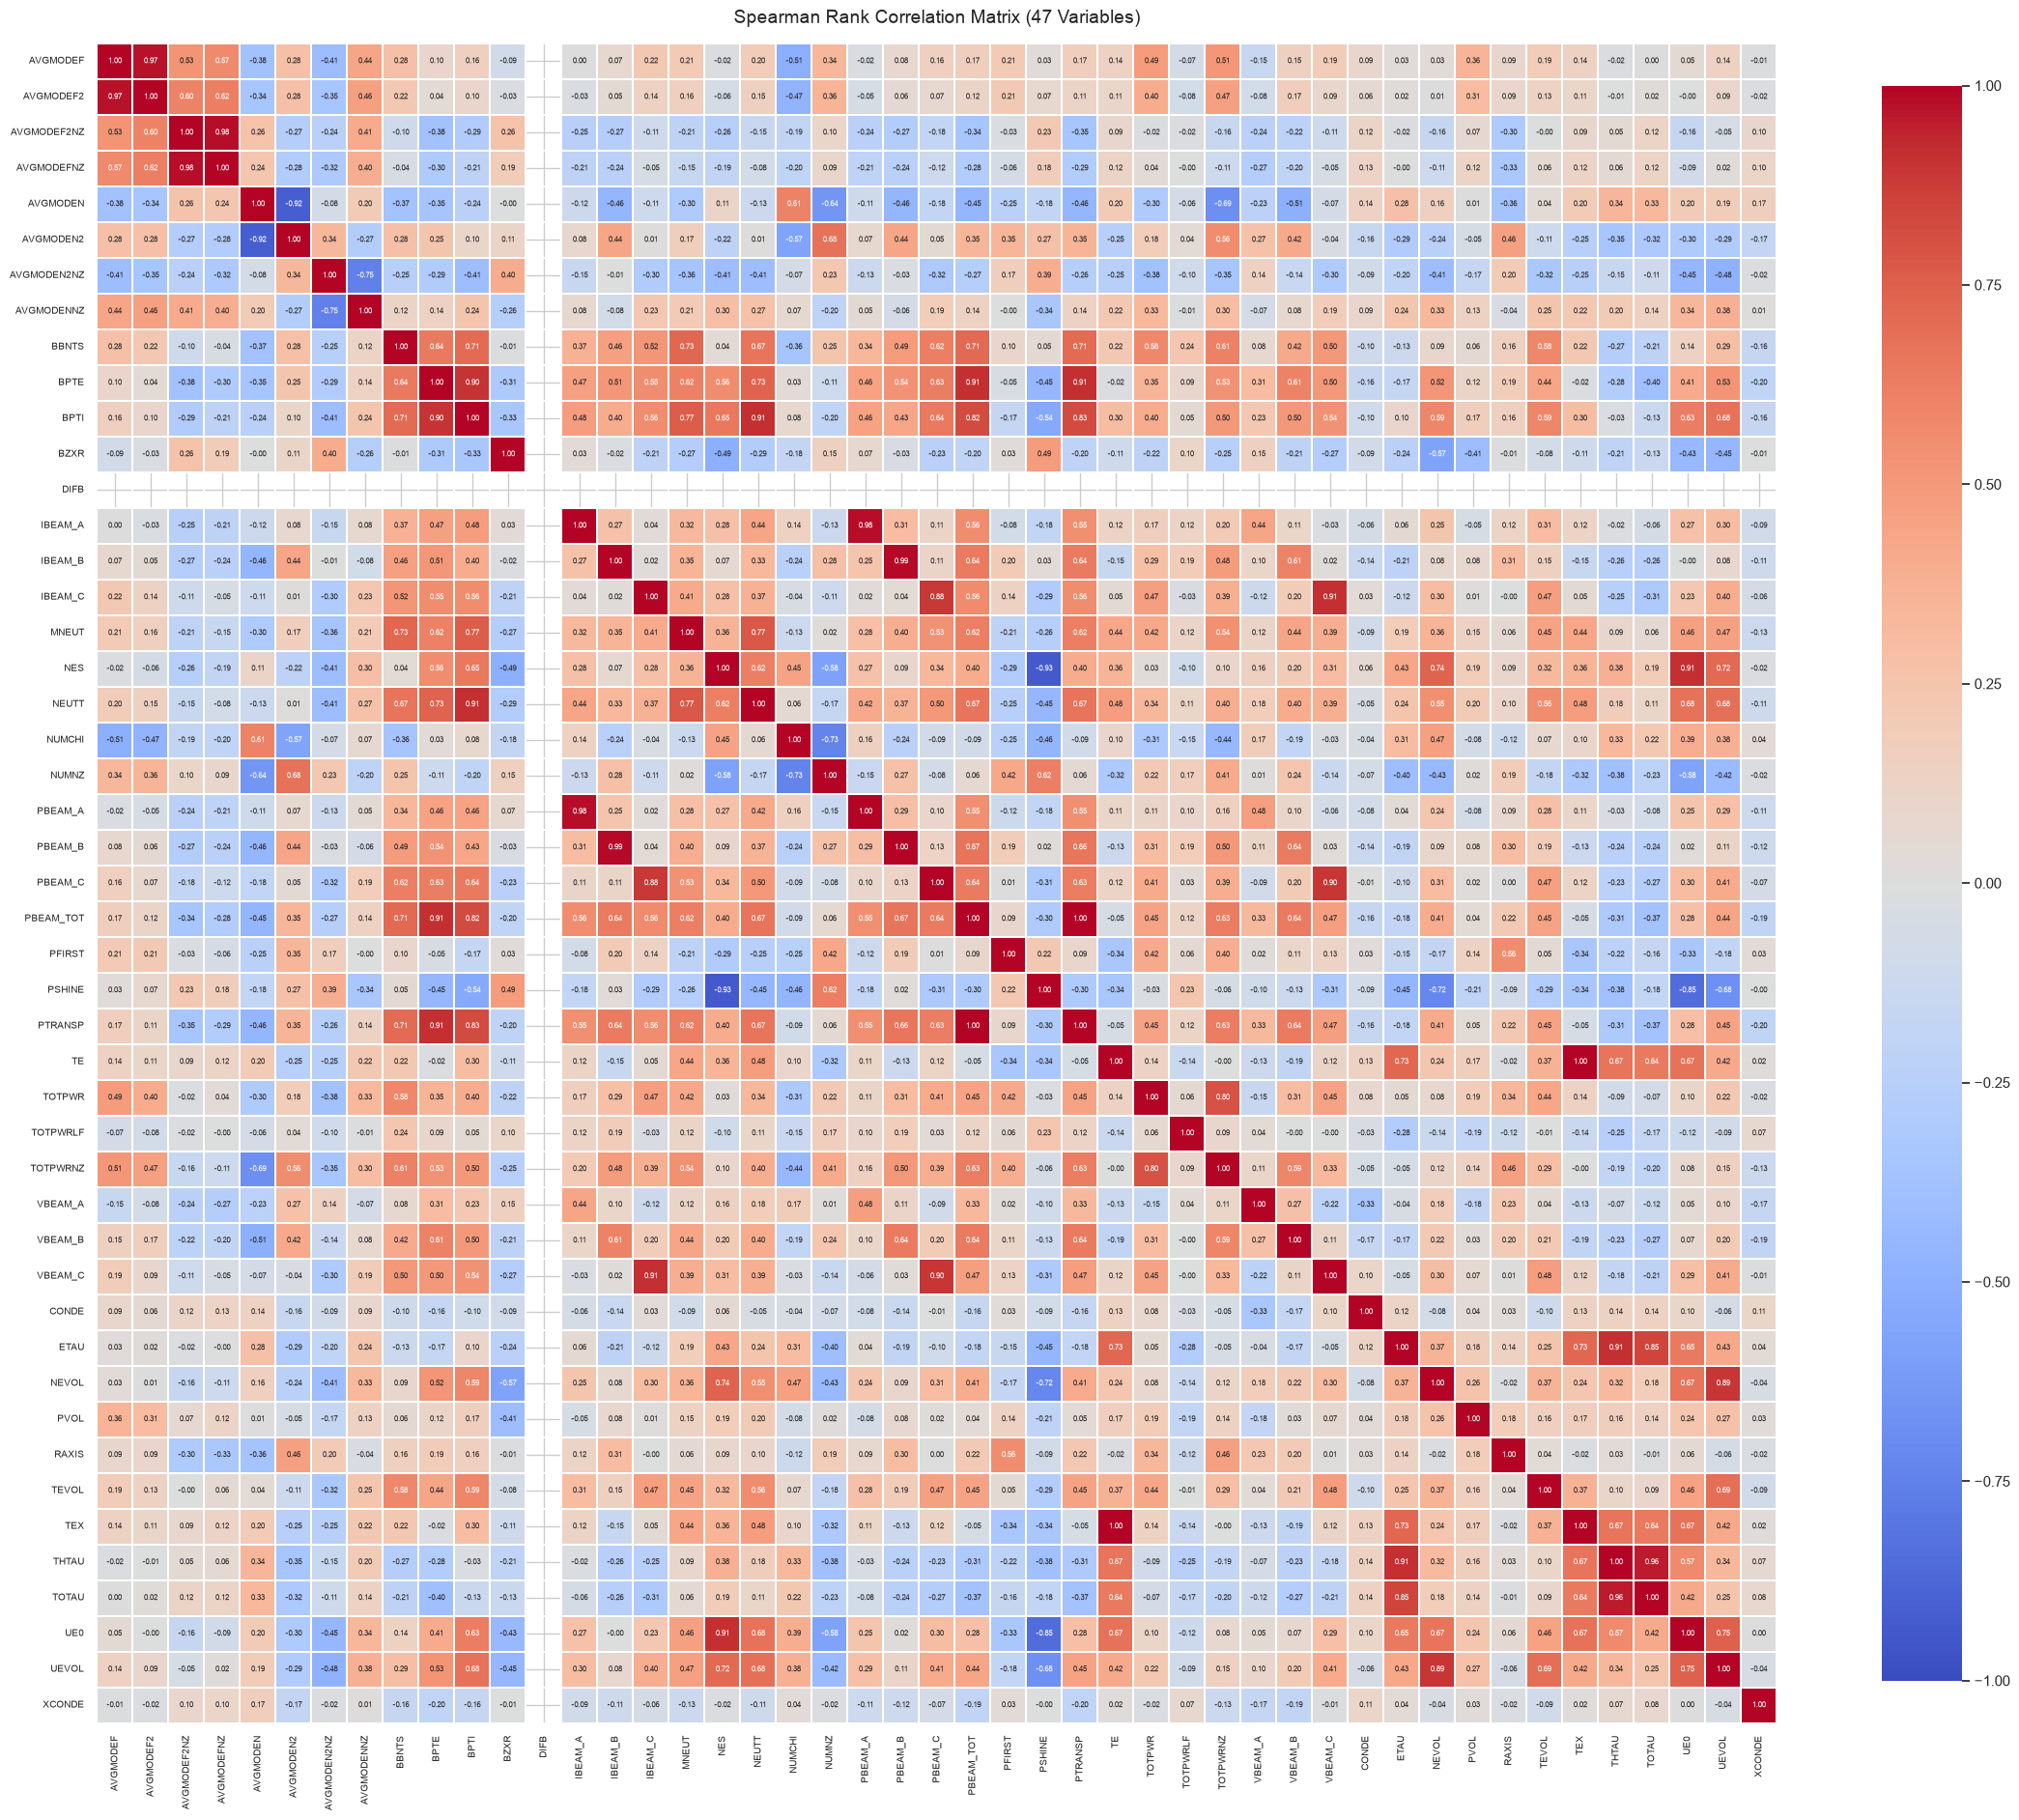


================ Correlation with ETAU ================
THTAU          0.909610
TOTAU          0.848422
TE             0.725674
TEX            0.725674
UE0            0.645220
NES            0.432828
UEVOL          0.426010
NEVOL          0.365518
NUMCHI         0.309456
AVGMODEN       0.277154
TEVOL          0.252349
AVGMODENNZ     0.244771
NEUTT          0.243614
MNEUT          0.185598
PVOL           0.176879
RAXIS          0.136038
CONDE          0.124477
BPTI           0.097301
IBEAM_A        0.062417
TOTPWR         0.049792
XCONDE         0.042851
PBEAM_A        0.040280
AVGMODEF       0.028371
AVGMODEF2      0.021705
AVGMODEFNZ    -0.003542
AVGMODEF2NZ   -0.015937
VBEAM_A       -0.039308
VBEAM_C       -0.050915
TOTPWRNZ      -0.051968
PBEAM_C       -0.098642
IBEAM_C       -0.117409
BBNTS         -0.125075
PFIRST        -0.150405
BPTE          -0.165067
VBEAM_B       -0.173850
PTRANSP       -0.181669
PBEAM_TOT     -0.182205
PBEAM_B       -0.192661
AVGMODEN2NZ   -0.196583
IBEAM_B

In [ ]:

# 1. Load Data
csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)

frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")


def norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())


col_map = {norm(c): c for c in frame.columns}

# 2. Identify target column (tau_e / ETAU) for target-specific correlation output
target_col = None
for alt in ("etau", "taue", "tau_e", "eta_u", "etaU"):
    alt_norm = norm(alt)
    if alt_norm in col_map:
        target_col = col_map[alt_norm]
        break

# 3. Select ALL numerical columns across the entire dataset
df_corr = frame.select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows found in the dataframe.")

print(
    f"Computing Spearman matrix for all {df_corr.shape[1]} numeric variables..."
)

# 4. Compute Spearman Correlation Matrix
corr = df_corr.corr(method="spearman")

# 5. Plot Large-Scale Heatmap (Scaled for ~40–50 features)
n_features = corr.shape[1]
fig_dim = max(16, int(n_features * 0.45))  # Dynamically scales figure size

plt.figure(figsize=(fig_dim + 2, fig_dim))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 6},  # Shrinks annotation font size so numbers fit
    cbar_kws={"shrink": 0.8},
)

plt.title(
    f"Spearman Rank Correlation Matrix ({n_features} Variables)",
    fontsize=14,
    pad=15,
)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# 6. Print Target Correlation Ranking
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print(
        f"\n================ Correlation with {target_col} ================"
    )
    print(corr_with_target.to_string())
else:
    print(
        "\nTarget column (ETAU/tau_e) was not found in the numeric columns."
    )




# Correlation Matrices of toroidal mode number and other non controlled variables

# ETAU clustering with Kmeans and PCA

================ CLUSTERING SANITY CHECK ================
Silhouette Score: 0.319
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 398 shots (39.8%)
  Cluster 1: 312 shots (31.2%)
  Cluster 2: 190 shots (19.0%)
  Cluster 3: 99 shots (9.9%)

--- Cluster Means ---


,THTAU,TE,UE0,TEX,ETAU
Cluster_Label,,,,,
2,0.060141,1098.462195,0.019628,1098.462195,0.057636
0,0.048275,931.143294,0.016652,931.143294,0.043973
1,0.034275,803.286441,0.011888,803.286441,0.031430
3,0.026914,676.175934,0.004196,676.175934,0.021326


/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_42954/2944164328.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


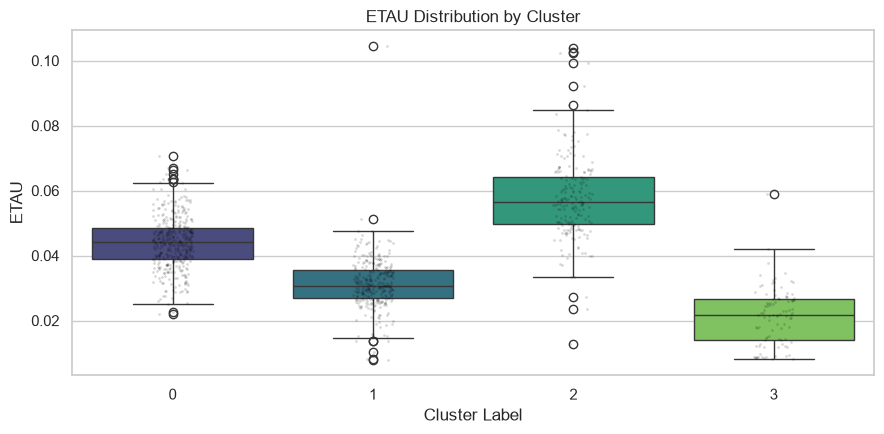

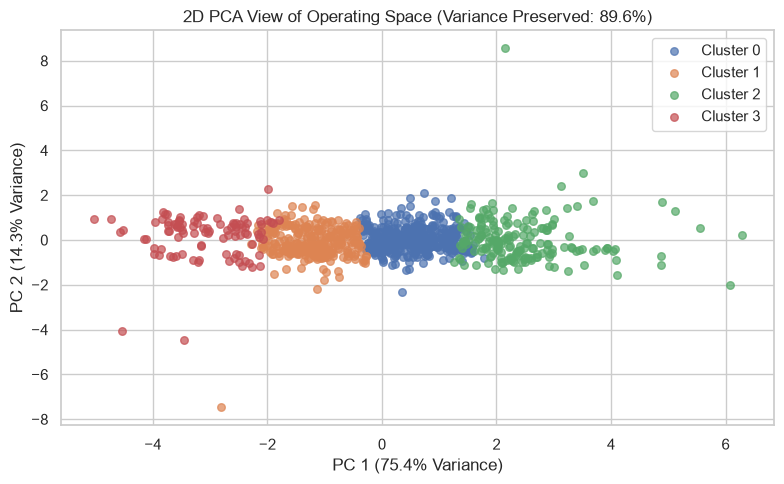

Features used: ['THTAU', 'TE', 'UE0', 'TEX']
Total rows clustered: 999


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Ensure Cell 14 variables are present
if "frame" not in globals() or "target_col" not in globals():
    raise NameError("Please run Cell 14 first to load `frame` and identify `target_col`.")

# 1. Define Features for Clustering
cluster_vars = [
    "THTAU", "TE", "UE0", "TEX"
]

selected_features = [c for c in cluster_vars if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])]

# 2. Filter & Clean Working Data
work_cols = selected_features + ([target_col] if target_col in frame.columns else [])
work = frame[work_cols].copy().replace([np.inf, -np.inf], np.nan).dropna()

if target_col in work.columns:
    work = work[work[target_col] > 0]  # Physical constraint
    low, high = work[target_col].quantile(0.01), work[target_col].quantile(0.99)
    work = work[(work[target_col] >= low) & (work[target_col] <= high)].copy()

# 3. Standardize Features & Run K-Means
X = work[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=25)
work["Cluster_Label"] = kmeans.fit_predict(X_scaled)

# --- 4. K-Means & PCA Sanity Checks ---
sil_score = silhouette_score(X_scaled, work["Cluster_Label"])
cluster_counts = work["Cluster_Label"].value_counts().sort_index()

print("================ CLUSTERING SANITY CHECK ================")
print(f"Silhouette Score: {sil_score:.3f}")
if sil_score > 0.5:
    print(" -> Assessment: Strong, well-separated cluster structure.")
elif sil_score > 0.25:
    print(" -> Assessment: Fair structure; expected overlap across continuous plasma regimes.")
else:
    print(" -> Assessment: Low separation; consider adjusting n_clusters or feature selection.")

print("\nCluster Size Balance:")
for label, count in cluster_counts.items():
    pct = (count / len(work)) * 100
    print(f"  Cluster {label}: {count} shots ({pct:.1f}%)")
print("=========================================================")

# 5. Cluster Summary Table
summary_cols = selected_features + ([target_col] if target_col in work.columns else [])
sort_by = target_col if target_col in work.columns else selected_features[0]
cluster_summary = work.groupby("Cluster_Label")[summary_cols].mean().sort_values(by=sort_by, ascending=False)

print("\n--- Cluster Means ---")
display(cluster_summary)

# 6. Plot Target Distribution Across Clusters
if target_col in work.columns:
    plt.figure(figsize=(9, 4.5))
    sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")
    sns.stripplot(data=work, x="Cluster_Label", y=target_col, color="black", alpha=0.15, size=2)
    plt.title(f"{target_col} Distribution by Cluster")
    plt.xlabel("Cluster Label")
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

# 7. Plot 2D PCA Space with Explained Variance Metrics
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100
total_var = var1 + var2

plt.figure(figsize=(8, 5))
for cl in sorted(work["Cluster_Label"].unique()):
    mask = (work["Cluster_Label"] == cl).values
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=30, alpha=0.7, label=f"Cluster {cl}")

plt.title(f"2D PCA View of Operating Space (Variance Preserved: {total_var:.1f}%)")
plt.xlabel(f"PC 1 ({var1:.1f}% Variance)")
plt.ylabel(f"PC 2 ({var2:.1f}% Variance)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features used: {selected_features}")
print(f"Total rows clustered: {len(work)}")

In [ ]:
pd.DataFrame(pca.components_, columns=selected_features, index=['PC1', 'PC2'])

,THTAU,TE,UE0,TEX
PC1,0.419266,0.548321,0.472128,0.548321
PC2,0.907461,-0.264065,-0.192496,-0.264065


# Spearman, KMeans and PCA with controlled variables (9/4)

Mapped columns for correlation: {'BZXR': 'mp_BZXR', 'PBEAM_A': 'PBEAM_A', 'PBEAM_B': 'PBEAM_B', 'PBEAM_C': 'PBEAM_C', 'PBEAM_TOT': 'PBEAM_TOT', 'PTRANSP': 'mp_PTRANSP', 'NES': 'mp_NES', 'tau_e': 'ETAU'}


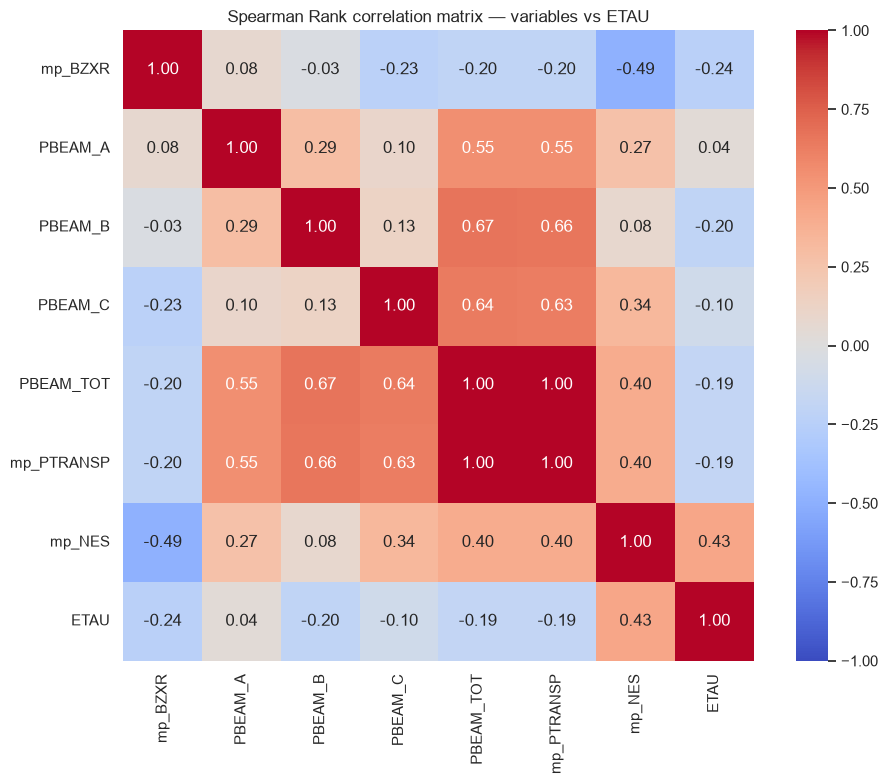


Correlation with ETAU
mp_NES        0.431232
PBEAM_A       0.038423
PBEAM_C      -0.100025
mp_PTRANSP   -0.185076
PBEAM_TOT    -0.185611
PBEAM_B      -0.195800
mp_BZXR      -0.235549


In [ ]:



# ...existing code...


csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)
frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")

def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())

col_map = {norm(c): c for c in frame.columns}

# robust matching for beam columns
candidates = {
    "BZXR": ["BZXR", "bzxr"],
    "PBEAM_A": ["PBEAM_A", "PBEAMA", "PBEAM A"],
    "PBEAM_B": ["PBEAM_B", "PBEAMB", "PBEAM B"],
    "PBEAM_C": ["PBEAM_C", "PBEAMC", "PBEAM C"],
    "PBEAM_TOT": ["PBEAM_TOT", "PBEAMTOT", "PBEAM TOT"],
    "PTRANSP": ["PTRANSP"],
    "NES": ["NES"]
    
}
# ...existing code...
found = {}
for key, toks in candidates.items():
    for t in toks:
        t_norm = norm(t)
        matches = [v for k, v in col_map.items() if t_norm in k]
        if matches:
            found[key] = matches[0]
            break

if "tau_e" not in found:
    for alt in ("taue", "etau", "tau_e", "eta_u", "etaU"):
        alt_norm = norm(alt)
        if alt_norm in col_map:
            found["tau_e"] = col_map[alt_norm]
            break
# ...existing code...

print("Mapped columns for correlation:", found)

use_cols = [v for k,v in found.items() if k in ("BZXR","PBEAM_A", "PBEAM_B", "PBEAM_C", "PBEAM_TOT", "PTRANSP", "NES", "tau_e")] #
df_corr = frame[use_cols].copy().select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows after dropna for selected columns.")

corr = df_corr.corr(method="spearman")

# heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Spearman Rank correlation matrix — variables vs ETAU")
plt.tight_layout()
plt.show()

# print sorted correlations with tau_e
target_col = found.get("tau_e")
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print("\nCorrelation with", target_col)
    print(corr_with_target.to_string())
else:
    print("Target column not found in computed correlation matrix.")
# ...existing code...




Mapped columns for correlation: {'CONDE': 'CONDE', 'PBEAM_A': 'PBEAM_A', 'PBEAM_B': 'PBEAM_B', 'PBEAM_C': 'PBEAM_C', 'AVGMODEF': 'AVGMODEF', 'AVGMODEN': 'AVGMODEN', 'TOTPWR': 'TOTPWR', 'tau_e': 'ETAU'}


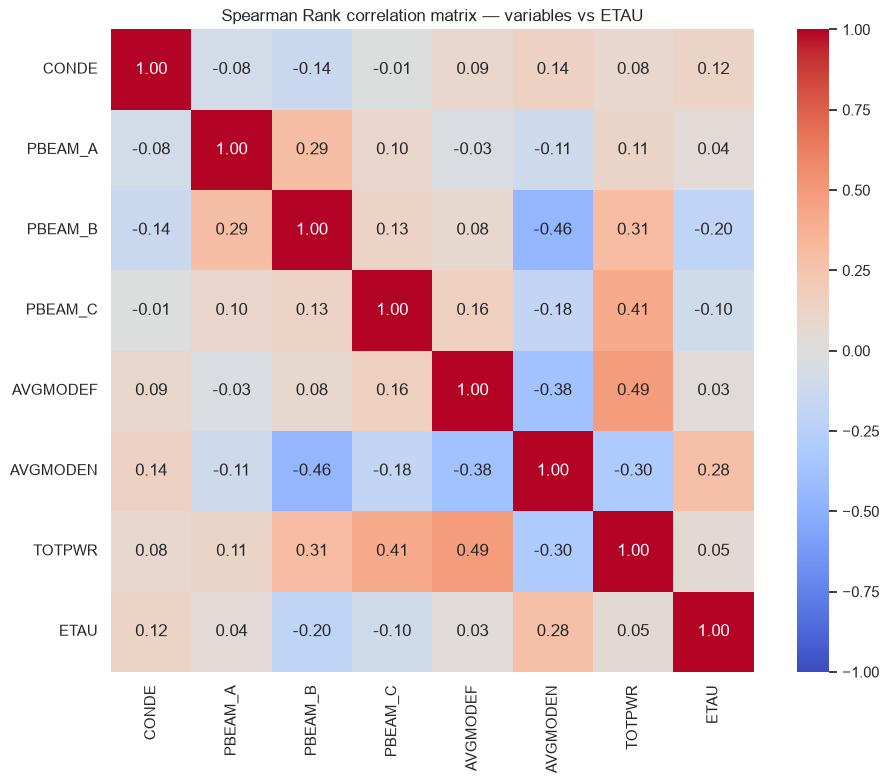


Correlation with ETAU
AVGMODEN    0.280645
CONDE       0.124317
TOTPWR      0.047811
PBEAM_A     0.038423
AVGMODEF    0.025715
PBEAM_C    -0.100025
PBEAM_B    -0.195800


In [ ]:



# ...existing code...


csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)
frame = pd.read_csv(csv_path)
frame.columns = frame.columns.str.strip().str.replace("\ufeff", "")

def norm(s): return "".join(ch for ch in str(s).lower() if ch.isalnum())

col_map = {norm(c): c for c in frame.columns}

# robust matching for beam columns

candidates = {
   "CONDE" : ["CONDE"],
   "PBEAM_A" : ["PBEAM_A"],
   "PBEAM_B" : ["PBEAM_B"],
   "PBEAM_C" : ["PBEAM_C"],
   "AVGMODEF" : ["AVGMODEF"],
   "AVGMODEN" : ["AVGMODEN"],
   "TOTPWR" : ["TOTPWR"]
}

# ...existing code...
found = {}
for key, toks in candidates.items():
    for t in toks:
        t_norm = norm(t)
        matches = [v for k, v in col_map.items() if t_norm in k]
        if matches:
            found[key] = matches[0]
            break

if "tau_e" not in found:
    for alt in ("taue", "etau", "tau_e", "eta_u", "etaU"):
        alt_norm = norm(alt)
        if alt_norm in col_map:
            found["tau_e"] = col_map[alt_norm]
            break
# ...existing code...

print("Mapped columns for correlation:", found)

use_cols = [v for k,v in found.items() if k in ("TOTPWR", "CONDE", "PBEAM_A", "PBEAM_B", "PBEAM_C", "AVGMODEF", "AVGMODEN", "tau_e")] #
df_corr = frame[use_cols].copy().select_dtypes(include=[np.number]).dropna()

if df_corr.empty:
    raise ValueError("No numeric rows after dropna for selected columns.")

corr = df_corr.corr(method="spearman")

# heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Spearman Rank correlation matrix — variables vs ETAU")
plt.tight_layout()
plt.show()

# print sorted correlations with tau_e
target_col = found.get("tau_e")
if target_col and target_col in corr.columns:
    corr_with_target = corr[target_col].drop(target_col).sort_values(ascending=False)
    print("\nCorrelation with", target_col)
    print(corr_with_target.to_string())
else:
    print("Target column not found in computed correlation matrix.")
# ...existing code...




In [4]:
plt.hist2d('AVGMODEN', 'ETAU', data = found, bins=40, cmap='viridis')
plt.colorbar(label = 'counts per bin')
plt.title('AVGMODEN and ETAU histogram')
plt.xlabel('AVGMODEN')
plt.ylabel('ETAU')
plt.grid(True)
plt.show()

NameError: name 'found' is not defined

--- Variance Explained (R^2) vs ETAU ---


,Variable,Spearman r,R^2 (Variance Explained),% Variance Explained
0,NES,0.4328,0.1873,18.73%
1,BZXR,-0.2377,0.0565,5.65%
2,PBEAM_B,-0.1927,0.0371,3.71%
3,PBEAM_TOT,-0.1822,0.0332,3.32%
4,PTRANSP,-0.1817,0.0330,3.30%
5,PBEAM_C,-0.0986,0.0097,0.97%
6,PBEAM_A,0.0403,0.0016,0.16%



--- Features Explaining >= 10% of Variance ---


,Variable,Spearman r,R^2 (Variance Explained),% Variance Explained
0,NES,0.432828,0.18734,18.734032


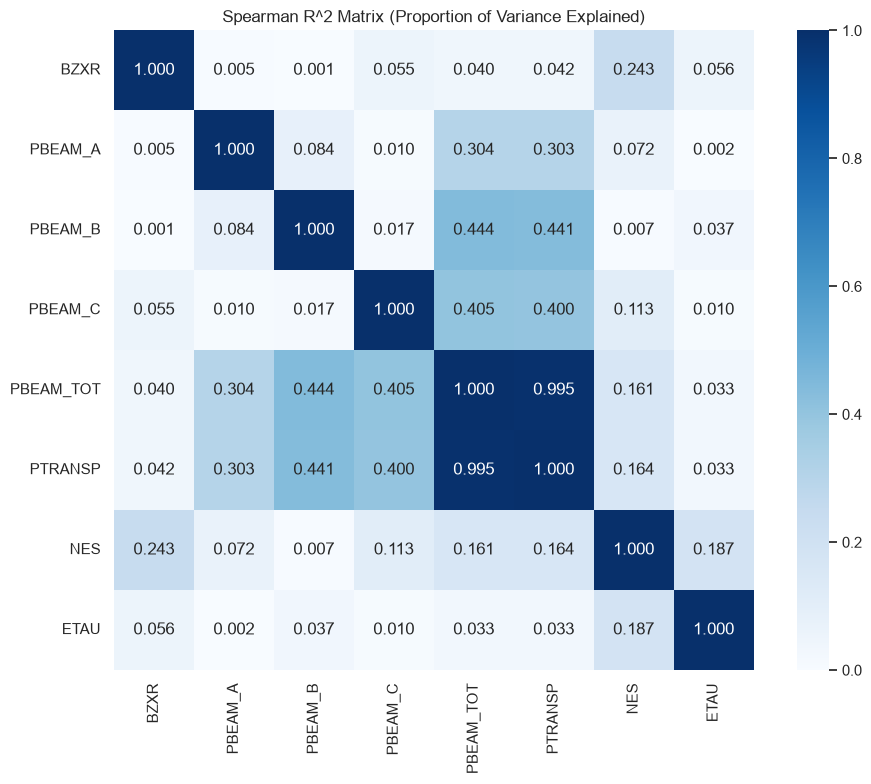

In [ ]:
# 1. Compute Spearman correlation matrix
corr = df_corr.corr(method="spearman")
target_col = found.get("tau_e")

if target_col and target_col in corr.columns:
    # 2. Extract correlation with target variable (excluding target itself)
    r_vec = corr[target_col].drop(target_col)

    # 3. Calculate R^2 (r squared)
    r2_df = pd.DataFrame(
        {
            "Variable": r_vec.index,
            "Spearman r": r_vec.values,
            "R^2 (Variance Explained)": r_vec.values ** 2,
            "% Variance Explained": (r_vec.values ** 2) * 100,
        }
    )

    # 4. Sort by R^2 descending
    r2_df = r2_df.sort_values(
        by="R^2 (Variance Explained)", ascending=False
    ).reset_index(drop=True)

    # Display clean table
    print(f"--- Variance Explained (R^2) vs {target_col} ---")
    display(
        r2_df.style.format(
            {
                "Spearman r": "{:.4f}",
                "R^2 (Variance Explained)": "{:.4f}",
                "% Variance Explained": "{:.2f}%",
            }
        )
    )

    # 5. Apply an explicit cutoff threshold (e.g., 10% variance explained)
    r2_threshold = 0.10  # 10%
    strong_features = r2_df[r2_df["R^2 (Variance Explained)"] >= r2_threshold]

    print(
        f"\n--- Features Explaining >= {r2_threshold*100:.0f}% of Variance ---"
    )
    display(strong_features)

else:
    print("Target column not found in correlation matrix.")

# Matrix of R^2 across all variables
r2_matrix = corr**2

plt.figure(figsize=(10, 8))
sns.heatmap(
    r2_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
)
plt.title("Spearman R^2 Matrix (Proportion of Variance Explained)")
plt.tight_layout()
plt.show()

================ CLUSTERING SANITY CHECK ================
Silhouette Score: 0.420
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 372 shots (37.2%)
  Cluster 1: 132 shots (13.2%)
  Cluster 2: 334 shots (33.4%)
  Cluster 3: 161 shots (16.1%)

--- Cluster Means ---


,BZXR,PBEAM_A,PBEAM_B,PBEAM_C,PBEAM_TOT,PTRANSP,NES,ETAU
Cluster_Label,,,,,,,,
3,37.583082,-0.000366,1.961619,1.516418,3.477672,3.473718,5.724205e+13,0.045923
0,39.543856,1.948273,1.989001,0.205367,4.142640,4.142843,6.547030e+13,0.042097
2,38.391222,1.962601,1.792041,1.825059,5.579701,5.581035,7.886683e+13,0.037508
1,42.565841,1.485532,0.078303,0.432242,1.996077,1.998150,4.513622e+13,0.036273


/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_42954/782522743.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


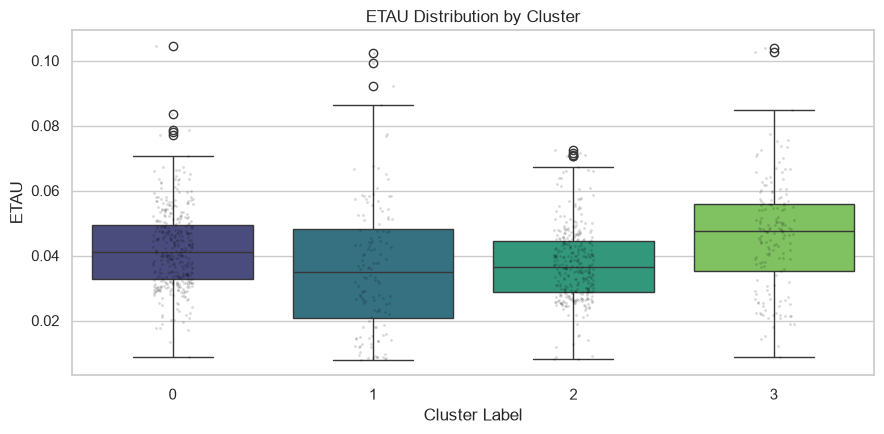


ETAU prediction using KMeans clusters: R^2 = 0.644
ETAU prediction using KMeans clusters: RMSE = 0.008


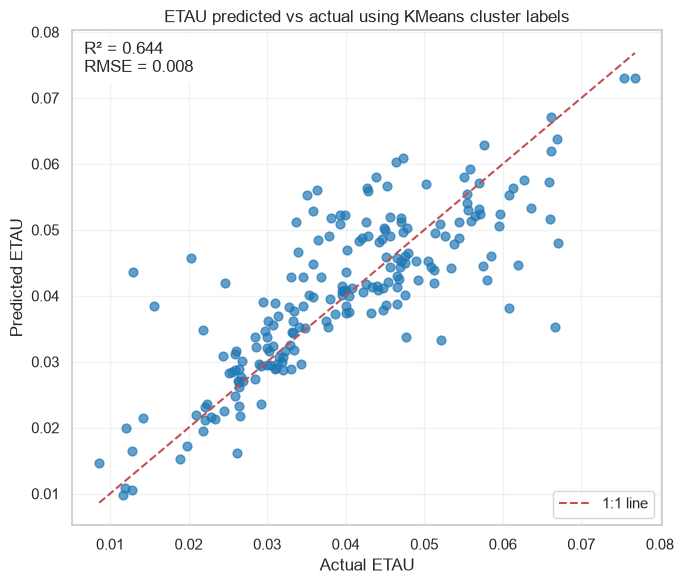

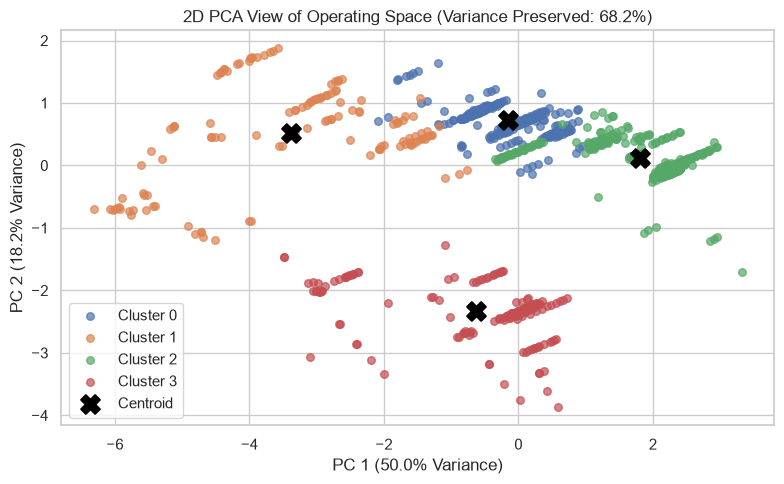

Features used: ['BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PTRANSP', 'NES']
Total rows clustered: 999


In [ ]:


# Ensure target and frame are present
if "frame" not in globals() or "target_col" not in globals():
    raise NameError("Please run the earlier cell that loads `frame` and identifies `target_col`.")

# 1. Define clustering feature set
cluster_vars = [
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "PBEAM_TOT",
    "PTRANSP",
    "NES"
]

selected_features = [
    c for c in cluster_vars
    if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])
]

# 2. Build working dataset
work_cols = selected_features + ([target_col] if target_col in frame.columns else [])
work = frame[work_cols].copy().replace([np.inf, -np.inf], np.nan).dropna()

if target_col in work.columns:
    work = work[work[target_col] > 0].copy()
    low, high = work[target_col].quantile(0.01), work[target_col].quantile(0.99)
    work = work[(work[target_col] >= low) & (work[target_col] <= high)].copy()

# 3. Cluster with KMeans
X = work[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=25)
work["Cluster_Label"] = kmeans.fit_predict(X_scaled)

# 4. Cluster sanity checks
sil_score = silhouette_score(X_scaled, work["Cluster_Label"])
cluster_counts = work["Cluster_Label"].value_counts().sort_index()

print("================ CLUSTERING SANITY CHECK ================")
print(f"Silhouette Score: {sil_score:.3f}")
if sil_score > 0.5:
    print(" -> Assessment: Strong, well-separated cluster structure.")
elif sil_score > 0.25:
    print(" -> Assessment: Fair structure; expected overlap across continuous plasma regimes.")
else:
    print(" -> Assessment: Low separation; consider adjusting n_clusters or feature selection.")

print("\nCluster Size Balance:")
for label, count in cluster_counts.items():
    pct = (count / len(work)) * 100
    print(f"  Cluster {label}: {count} shots ({pct:.1f}%)")
print("=========================================================")

# 5. Cluster summary table
summary_cols = selected_features + ([target_col] if target_col in work.columns else [])
sort_by = target_col if target_col in work.columns else selected_features[0]
cluster_summary = work.groupby("Cluster_Label")[summary_cols].mean().sort_values(by=sort_by, ascending=False)

print("\n--- Cluster Means ---")
display(cluster_summary)

# 6. Plot ETAU by cluster
if target_col in work.columns:
    plt.figure(figsize=(9, 4.5))
    sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")
    sns.stripplot(data=work, x="Cluster_Label", y=target_col, color="black", alpha=0.15, size=2)
    plt.title(f"{target_col} Distribution by Cluster")
    plt.xlabel("Cluster Label")
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

# 7. Predict ETAU using cluster label + original features
if target_col in work.columns:
    X_model = work[selected_features + ["Cluster_Label"]].copy()
    y_model = work[target_col].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X_model, y_model, test_size=0.2, random_state=42
    )

    etau_model = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        max_depth=12,
        min_samples_leaf=2
    )
    etau_model.fit(X_train, y_train)

    y_pred = etau_model.predict(X_test)
    eta_r2 = r2_score(y_test, y_pred)
    eta_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\nETAU prediction using KMeans clusters: R^2 = {eta_r2:.3f}")
    print(f"ETAU prediction using KMeans clusters: RMSE = {eta_rmse:.3f}")

    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, y_pred, s=40, alpha=0.7, color="tab:blue")
    min_v = min(y_test.min(), y_pred.min())
    max_v = max(y_test.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "r--", lw=1.5, label="1:1 line")
    plt.xlabel(f"Actual {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(f"{target_col} predicted vs actual using KMeans cluster labels")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.text(
        0.02, 0.98,
        f"R² = {eta_r2:.3f}\nRMSE = {eta_rmse:.3f}",
        transform=plt.gca().transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9)
    )
    plt.tight_layout() 
    plt.show()

# 8. PCA view of cluster space
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100
total_var = var1 + var2

plt.figure(figsize=(8, 5))
for cl in sorted(work["Cluster_Label"].unique()):
    mask = (work["Cluster_Label"] == cl).values
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=30, alpha=0.7, label=f"Cluster {cl}")

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=180,
    marker="X",
    c="black",
    linewidths=1.5,
    label="Centroid"
)

plt.title(f"2D PCA View of Operating Space (Variance Preserved: {total_var:.1f}%)")
plt.xlabel(f"PC 1 ({var1:.1f}% Variance)")
plt.ylabel(f"PC 2 ({var2:.1f}% Variance)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features used: {selected_features}")
print(f"Total rows clustered: {len(work)}")

================ CLUSTERING SANITY CHECK ================
Silhouette Score: 0.420
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 372 shots (37.2%)
  Cluster 1: 132 shots (13.2%)
  Cluster 2: 334 shots (33.4%)
  Cluster 3: 161 shots (16.1%)

--- Cluster Means ---


,BZXR,PBEAM_A,PBEAM_B,PBEAM_C,PBEAM_TOT,PTRANSP,NES,ETAU
Cluster_Label,,,,,,,,
3,37.583082,-0.000366,1.961619,1.516418,3.477672,3.473718,5.724205e+13,0.045923
0,39.543856,1.948273,1.989001,0.205367,4.142640,4.142843,6.547030e+13,0.042097
2,38.391222,1.962601,1.792041,1.825059,5.579701,5.581035,7.886683e+13,0.037508
1,42.565841,1.485532,0.078303,0.432242,1.996077,1.998150,4.513622e+13,0.036273


/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_42954/2656969084.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


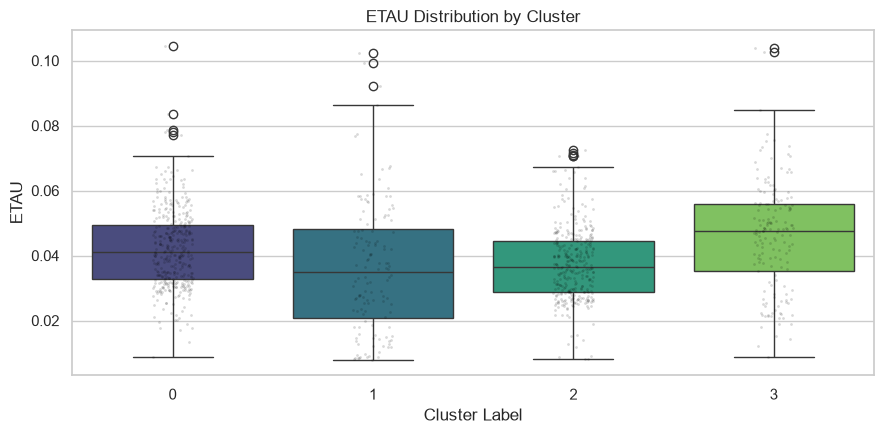

CV R^2 (5-fold): -0.227 +/- 0.185

ETAU prediction (holdout): R^2 = 0.646, RMSE = 0.008

Top features:
 NES          0.349474
PTRANSP      0.175312
PBEAM_TOT    0.147665
BZXR         0.097817
PBEAM_B      0.095742
PBEAM_A      0.080951
PBEAM_C      0.044437
CL_3         0.005195
CL_2         0.002388
CL_1         0.001018


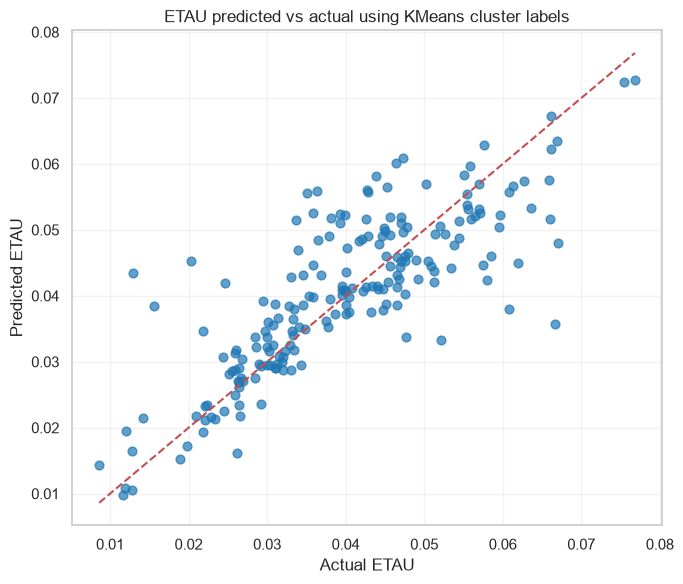

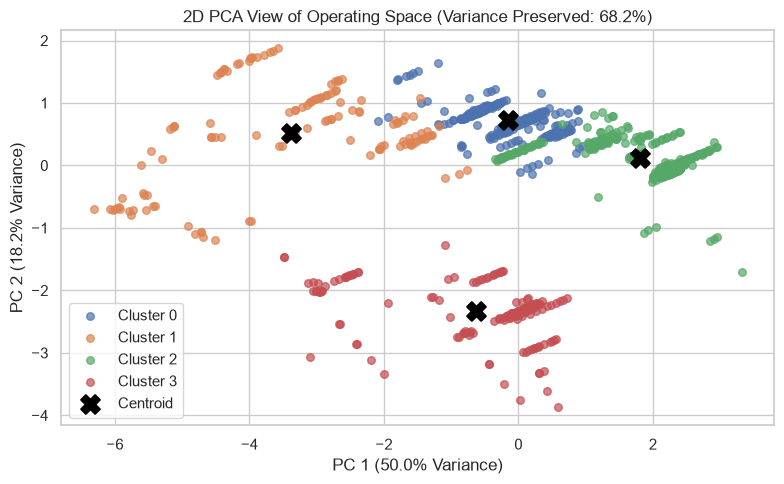

Features used: ['BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PTRANSP', 'NES']
Total rows clustered: 999


In [ ]:


# Ensure target and frame are present
if "frame" not in globals() or "target_col" not in globals():
    raise NameError("Please run the earlier cell that loads `frame` and identifies `target_col`.")

# 1. Define clustering feature set
cluster_vars = [
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "PBEAM_TOT",
    "PTRANSP",
    "NES"
]

selected_features = [
    c for c in cluster_vars
    if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])
]

# 2. Build working dataset
work_cols = selected_features + ([target_col] if target_col in frame.columns else [])
work = frame[work_cols].copy().replace([np.inf, -np.inf], np.nan).dropna()

if target_col in work.columns:
    work = work[work[target_col] > 0].copy()
    low, high = work[target_col].quantile(0.01), work[target_col].quantile(0.99)
    work = work[(work[target_col] >= low) & (work[target_col] <= high)].copy()

# 3. Cluster with KMeans
X = work[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=25)
work["Cluster_Label"] = kmeans.fit_predict(X_scaled)

# 4. Cluster sanity checks
sil_score = silhouette_score(X_scaled, work["Cluster_Label"])
cluster_counts = work["Cluster_Label"].value_counts().sort_index()

print("================ CLUSTERING SANITY CHECK ================")
print(f"Silhouette Score: {sil_score:.3f}")
if sil_score > 0.5:
    print(" -> Assessment: Strong, well-separated cluster structure.")
elif sil_score > 0.25:
    print(" -> Assessment: Fair structure; expected overlap across continuous plasma regimes.")
else:
    print(" -> Assessment: Low separation; consider adjusting n_clusters or feature selection.")

print("\nCluster Size Balance:")
for label, count in cluster_counts.items():
    pct = (count / len(work)) * 100
    print(f"  Cluster {label}: {count} shots ({pct:.1f}%)")
print("=========================================================")

# 5. Cluster summary table
summary_cols = selected_features + ([target_col] if target_col in work.columns else [])
sort_by = target_col if target_col in work.columns else selected_features[0]
cluster_summary = work.groupby("Cluster_Label")[summary_cols].mean().sort_values(by=sort_by, ascending=False)

print("\n--- Cluster Means ---")
display(cluster_summary)

# 6. Plot ETAU by cluster
if target_col in work.columns:
    plt.figure(figsize=(9, 4.5))
    sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")
    sns.stripplot(data=work, x="Cluster_Label", y=target_col, color="black", alpha=0.15, size=2)
    plt.title(f"{target_col} Distribution by Cluster")
    plt.xlabel("Cluster Label")
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

# ...existing code...
# 7. Predict ETAU using cluster label + original features (improved)
if target_col in work.columns:
    # One-hot encode cluster label to treat it as categorical
    X_model = work[selected_features + ["Cluster_Label"]].copy()
    if "Cluster_Label" in X_model.columns:
        X_model = pd.get_dummies(X_model, columns=["Cluster_Label"], prefix="CL", drop_first=True)

    y_model = work[target_col].astype(float)

    # CV evaluation
    from sklearn.model_selection import cross_val_score
    rf = RandomForestRegressor(n_estimators=400, random_state=42, max_depth=12, min_samples_leaf=2, n_jobs=-1)
    cv_r2 = cross_val_score(rf, X_model, y_model, cv=5, scoring="r2")
    print(f"CV R^2 (5-fold): {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}")

    # Train / test split for diagnostics and feature importances
    X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    eta_r2 = r2_score(y_test, y_pred)
    eta_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nETAU prediction (holdout): R^2 = {eta_r2:.3f}, RMSE = {eta_rmse:.3f}")

    # Feature importance (sorted)
    fi = pd.Series(rf.feature_importances_, index=X_model.columns).sort_values(ascending=False)
    print("\nTop features:\n", fi.head(10).to_string())

    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, y_pred, s=40, alpha=0.7, color="tab:blue")
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], "r--", lw=1.5)
    plt.xlabel(f"Actual {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(f"{target_col} predicted vs actual using KMeans cluster labels")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
# ...existing code...

# 8. PCA view of cluster space
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100
total_var = var1 + var2

plt.figure(figsize=(8, 5))
for cl in sorted(work["Cluster_Label"].unique()):
    mask = (work["Cluster_Label"] == cl).values
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=30, alpha=0.7, label=f"Cluster {cl}")

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=180,
    marker="X",
    c="black",
    linewidths=1.5,
    label="Centroid"
)

plt.title(f"2D PCA View of Operating Space (Variance Preserved: {total_var:.1f}%)")
plt.xlabel(f"PC 1 ({var1:.1f}% Variance)")
plt.ylabel(f"PC 2 ({var2:.1f}% Variance)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features used: {selected_features}")
print(f"Total rows clustered: {len(work)}")

In [ ]:
# ...existing code...
pca_features = X.columns.tolist()  # exactly what PCA used
pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1", "PC2"]
)

,PC1,PC2
BZXR,-0.284271,0.359478
PBEAM_A,0.198356,0.791411
PBEAM_B,0.339765,-0.152411
PBEAM_C,0.328606,-0.429572
PBEAM_TOT,0.518066,0.081881
PTRANSP,0.518091,0.083545
NES,0.345849,0.151652


Using clustering features: ['BZXR', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PTRANSP', 'NES']


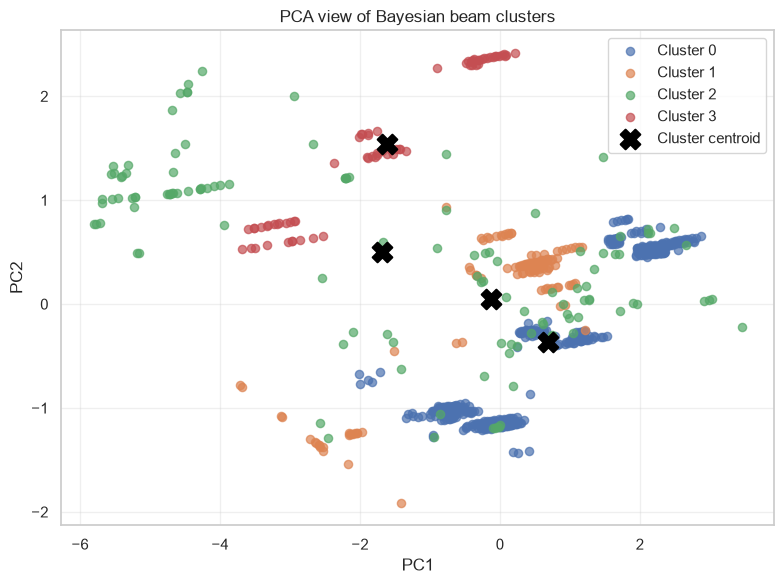

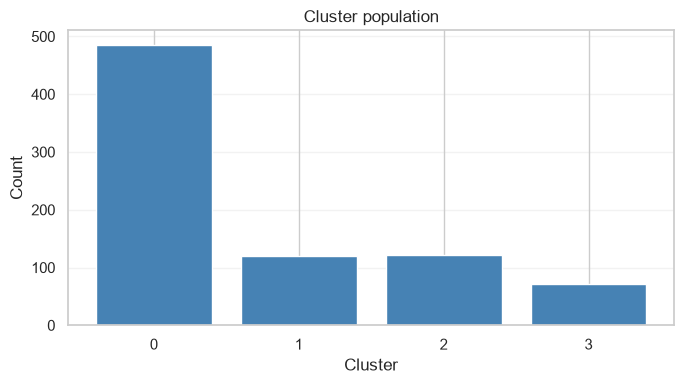

/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_42954/2186518769.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Cluster", y="ETAU", palette="viridis")


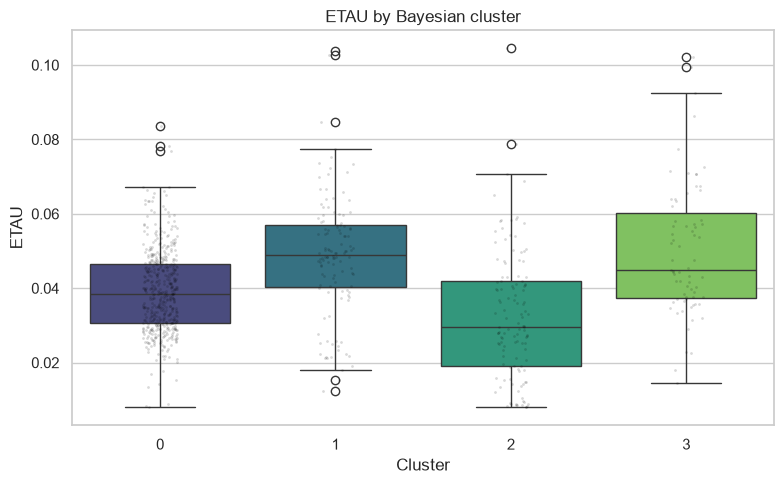

Silhouette score: 0.198
Bayesian clustered ETAU model: R² = 0.428, RMSE = 0.010

Cluster summary for ETAU:
 cluster  n_train  mean_eta  std_eta
       0      486  0.039180 0.011006
       1      120  0.048582 0.016303
       2      122  0.032691 0.017255
       3       71  0.050100 0.017837


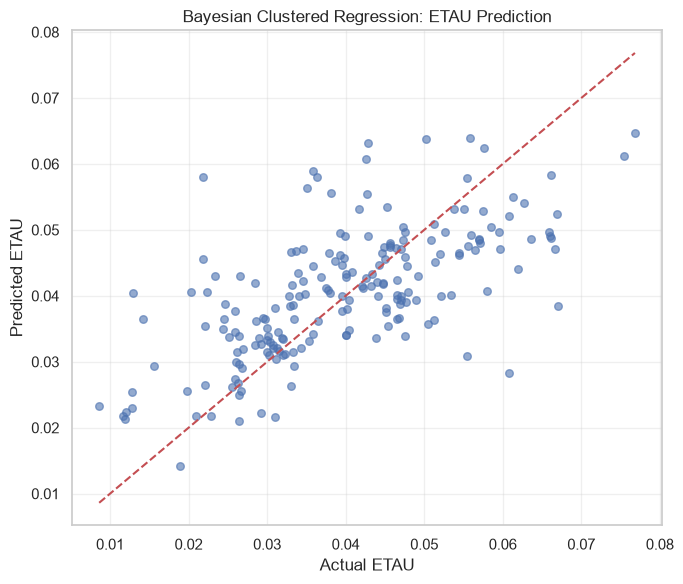

In [ ]:


# ------------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------------
csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

# find ETAU / tau_e target
target_col = None
for alt in ("ETAU", "etau", "tau_e", "taue"):
    if alt in df.columns:
        target_col = alt
        break

if target_col is None:
    raise ValueError("No ETAU/tau_e target column found in the CSV.")

# ------------------------------------------------------------------
# 2) Restrict clustering to the beam-related variables you specified
# ------------------------------------------------------------------
cluster_vars = [
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "PBEAM_TOT",
    "PTRANSP",
    "NES"
]

# keep only numeric, present columns
feature_cols = [
    c for c in cluster_vars
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]

if not feature_cols:
    raise ValueError("None of the requested cluster variables were found as numeric columns.")

# ------------------------------------------------------------------
# 3) Build clean dataframe: use only those vars + target
# ------------------------------------------------------------------
df_model = df[feature_cols + [target_col]].copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
df_model = df_model[df_model[target_col] > 0].copy()

# optional trim on target to remove extremes
low, high = df_model[target_col].quantile(0.01), df_model[target_col].quantile(0.99)
df_model = df_model[(df_model[target_col] >= low) & (df_model[target_col] <= high)].copy()

# ------------------------------------------------------------------
# 4) Keep only variables with meaningful Spearman correlation to ETAU
# ------------------------------------------------------------------
corr = df_model[feature_cols + [target_col]].corr(method="spearman")
rho = corr[target_col].drop(target_col).abs()
feature_cols = rho[rho > 0.05].index.tolist()

if not feature_cols:
    feature_cols = feature_cols if feature_cols else cluster_vars[:min(5, len(cluster_vars))]
    print("No variable exceeded |rho| > 0.05; using top available subset instead.")

print(f"Using clustering features: {feature_cols}")

# ------------------------------------------------------------------
# 5) Final split and clustering
# ------------------------------------------------------------------
X = df_model[feature_cols].astype(float)
y = df_model[target_col].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

gmm = BayesianGaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    reg_covar=1e-6,
    weight_concentration_prior_type="dirichlet_distribution",
    max_iter=500,
    n_init=5
)

train_clusters = gmm.fit_predict(X_train_s)
test_cluster_probs = gmm.predict_proba(X_test_s)

# ------------------------------------------------------------------
# 6) Cluster-specific Bayesian Ridge models
# ------------------------------------------------------------------
cluster_models = {}
for k in range(gmm.n_components):
    mask = train_clusters == k
    if mask.sum() < 5:
        continue
    model = BayesianRidge()
    model.fit(X_train_s[mask], y_train.to_numpy()[mask])
    cluster_models[k] = model

# ------------------------------------------------------------------
# 7) Visualize Bayesian clusters
# ------------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_s)

df_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": train_clusters,
    "ETAU": y_train.to_numpy()
})

centroids_pca = pca.transform(gmm.means_)

plt.figure(figsize=(8, 6))
for k in sorted(df_plot["Cluster"].unique()):
    sub = df_plot[df_plot["Cluster"] == k]
    plt.scatter(sub["PC1"], sub["PC2"], s=35, alpha=0.7, label=f"Cluster {k}")

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    marker="X",
    c="black",
    linewidths=1.5,
    label="Cluster centroid"
)
plt.title("PCA view of Bayesian beam clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cluster size bar chart
cluster_counts = df_plot["Cluster"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color="steelblue")
plt.title("Cluster population")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ETAU distribution by cluster
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x="Cluster", y="ETAU", palette="viridis")
sns.stripplot(data=df_plot, x="Cluster", y="ETAU", color="black", alpha=0.15, size=2)
plt.title("ETAU by Bayesian cluster")
plt.xlabel("Cluster")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

sil = silhouette_score(X_train_s, train_clusters)
print(f"Silhouette score: {sil:.3f}")

# ------------------------------------------------------------------
# 8) Weighted prediction from cluster probabilities
# ------------------------------------------------------------------
preds = []
for i in range(len(X_test_s)):
    probs = test_cluster_probs[i]
    pred_values = []
    for k, p in enumerate(probs):
        if k in cluster_models and p > 0:
            pred_k = cluster_models[k].predict(X_test_s[i:i+1])[0]
            pred_values.append(p * pred_k)
    if len(pred_values) == 0:
        preds.append(float(np.median(y_train)))
    else:
        preds.append(float(sum(pred_values)))

preds = np.asarray(preds)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Bayesian clustered ETAU model: R² = {r2:.3f}, RMSE = {rmse:.3f}")

# ------------------------------------------------------------------
# 9) Cluster summaries
# ------------------------------------------------------------------
cluster_summary = []
for k in range(gmm.n_components):
    mask = train_clusters == k
    if mask.sum() == 0:
        continue
    cluster_summary.append({
        "cluster": k,
        "n_train": int(mask.sum()),
        "mean_eta": float(y_train.iloc[mask].mean()),
        "std_eta": float(y_train.iloc[mask].std(ddof=1)),
    })

cluster_summary = pd.DataFrame(cluster_summary)
print("\nCluster summary for ETAU:")
print(cluster_summary.to_string(index=False))

# ------------------------------------------------------------------
# 10) Actual vs predicted
# ------------------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_test, preds, alpha=0.6, s=30)
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5)
plt.xlabel("Actual ETAU")
plt.ylabel("Predicted ETAU")
plt.title("Bayesian Clustered Regression: ETAU Prediction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bayesian Clustering + other tests

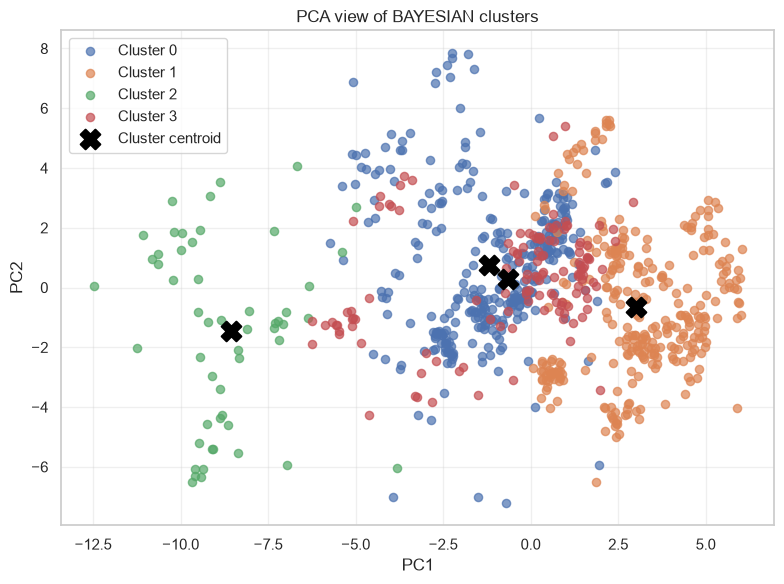

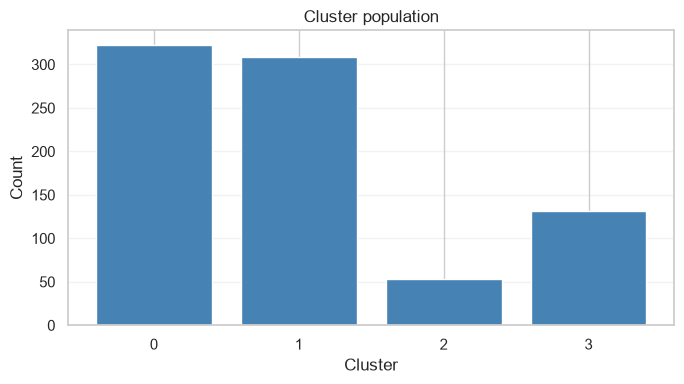

/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_42954/4251279030.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Cluster", y="ETAU", palette="viridis")


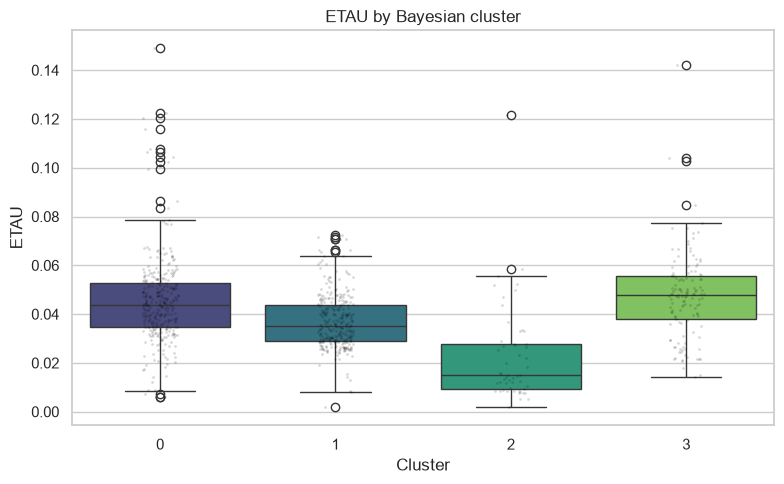

Silhouette score: 0.186
Bayesian clustering ETAU model: R² = 0.847, RMSE = 0.007

Cluster summary for ETAU:
 cluster  n_train  mean_eta  std_eta
       0      323  0.045231 0.017785
       1      309  0.037001 0.010976
       2       53  0.022745 0.020166
       3      131  0.047641 0.018281


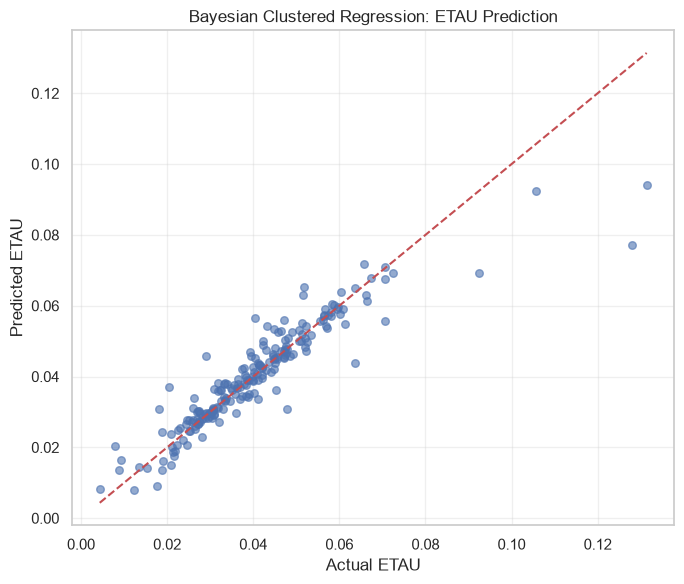

In [ ]:
# Bayesian clustering + cluster-aware regression for ETAU



# ------------------------------------------------------------------
# 1) Load the CSV
# ------------------------------------------------------------------
csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

# find ETAU / tau_e target
target_col = None
for alt in ("ETAU", "etau", "tau_e", "taue"):
    if alt in df.columns:
        target_col = alt
        break

if target_col is None:
    raise ValueError("No ETAU/tau_e target column found in the CSV.")

# optional: keep only non-target numeric columns
feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != target_col
]

# clean
df_model = df[feature_cols + [target_col]].copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
df_model = df_model[df_model[target_col] > 0].copy()

# final features and target
X = df_model[feature_cols].astype(float).copy()
y = df_model[target_col].astype(float).copy()

# ------------------------------------------------------------------
# 2) Split data
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------------
# 3) Standardize features for clustering/regression
# ------------------------------------------------------------------
scaler = StandardScaler()                                               #IS STANDARD SCALER NECESSARY?
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ------------------------------------------------------------------
# 4) Bayesian Gaussian Mixture clustering
# ------------------------------------------------------------------
gmm = BayesianGaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    reg_covar=1e-6,
    weight_concentration_prior_type="dirichlet_distribution",
    max_iter=500,
    n_init=5
)

train_clusters = gmm.fit_predict(X_train_s)
test_cluster_probs = gmm.predict_proba(X_test_s)

# ------------------------------------------------------------------
# 5) Cluster-specific Bayesian Ridge models
# ------------------------------------------------------------------
cluster_models = {}
for k in range(gmm.n_components):
    mask = train_clusters == k
    if mask.sum() < 5:
        continue

    model = BayesianRidge()
    model.fit(X_train_s[mask], y_train.iloc[mask].values)
    cluster_models[k] = model

# ------------------------------------------------------------------
# Visualize the Bayesian clusters
# ------------------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1) PCA projection for 2D cluster view
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_s)

df_plot = pd.DataFrame(
    {"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Cluster": train_clusters, "ETAU": y_train.values}
)

# cluster centroid positions in the PCA plane
centroids_pca = pca.transform(gmm.means_)

plt.figure(figsize=(8, 6))
for k in sorted(df_plot["Cluster"].unique()):
    sub = df_plot[df_plot["Cluster"] == k]
    plt.scatter(sub["PC1"], sub["PC2"], s=35, alpha=0.7, label=f"Cluster {k}")

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    marker="X",
    c="black",
    linewidths=1.5,
    label="Cluster centroid"
)
plt.title("PCA view of BAYESIAN clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Cluster size bar chart
cluster_counts = df_plot["Cluster"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color="steelblue")
plt.title("Cluster population")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# 3) ETAU distribution by cluster
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x="Cluster", y="ETAU", palette="viridis")
sns.stripplot(data=df_plot, x="Cluster", y="ETAU", color="black", alpha=0.15, size=2)
plt.title("ETAU by Bayesian cluster")
plt.xlabel("Cluster")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

# 4) Optional silhouette score for cluster separation
sil = silhouette_score(X_train_s, train_clusters)
print(f"Silhouette score: {sil:.3f}")

# ------------------------------------------------------------------
# 6) Weighted prediction: cluster probability * cluster model prediction
# ------------------------------------------------------------------
preds = []
for i in range(len(X_test_s)):
    probs = test_cluster_probs[i]
    pred_values = []
    for k, p in enumerate(probs):
        if k in cluster_models and p > 0:
            pred_k = cluster_models[k].predict(X_test_s[i:i+1])[0]
            pred_values.append(p * pred_k)
    if len(pred_values) == 0:
        preds.append(float(np.median(y_train)))
    else:
        preds.append(float(sum(pred_values)))

preds = np.asarray(preds)

# metrics
r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"Bayesian clustering ETAU model: R² = {r2:.3f}, RMSE = {rmse:.3f}")

# ------------------------------------------------------------------
# 7) Cluster summaries
# ------------------------------------------------------------------
cluster_summary = []
for k in range(gmm.n_components):
    mask = train_clusters == k
    if mask.sum() == 0:
        continue
    cluster_summary.append({
        "cluster": k,
        "n_train": int(mask.sum()),
        "mean_eta": float(y_train.iloc[mask].mean()),
        "std_eta": float(y_train.iloc[mask].std(ddof=1)),
    })

cluster_summary = pd.DataFrame(cluster_summary)
print("\nCluster summary for ETAU:")
print(cluster_summary.to_string(index=False))

# ------------------------------------------------------------------
# 8) Diagnostic plot: actual vs predicted
# ------------------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_test, preds, alpha=0.6, s=30)
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5)
plt.xlabel("Actual ETAU")
plt.ylabel("Predicted ETAU")
plt.title("Bayesian Clustered Regression: ETAU Prediction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:


# Build the dataframe from notebook-defined objects only
if "df_raw" not in globals():
    df_raw = load_and_clean_data(filepath=None)

if "df_engineered" not in globals():
    df_engineered, X_cols, Y_wave_cols, Y_target_col = engineer_features(df_raw)

# Use the engineered features from this notebook
feature_cols = ['P_beam', 'B_T', 'I_P', 'n_e', 'f_norm', 'n_norm', 'dB2']

X = df_engineered[feature_cols].copy()
y = df_engineered['tau_e'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Target transform for skewed tau_e
y_train_log = np.log1p(y_train)

model = make_pipeline(
    RobustScaler(),
    LassoCV(cv=5, random_state=42)
)

model.fit(X_train, y_train_log)

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"R2: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R2: 0.371
RMSE: 0.010


In [ ]:


def train_pipeline(df, X_control_cols, Y_wave_cols, Y_target_col):
    """
    Trains the 2-stage surrogate model using RobustScaler for the confinement stage.
    """
    print("\n--- Training Stage 1: The 'Wave Predictor' ---")
    X1 = df[X_control_cols]
    Y1 = df[Y_wave_cols]

    X1_train, X1_test, Y1_train, Y1_test = train_test_split(
        X1, Y1, test_size=0.2, random_state=42
    )

    # Wave model: tree-based, scaling is not essential here
    wave_model = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42)
    )
    wave_model.fit(X1_train, Y1_train)

    Y1_pred = wave_model.predict(X1_test)
    print(f"Wave Predictor R^2 Score: {r2_score(Y1_test, Y1_pred):.3f}")

    print("\n--- Training Stage 2: The 'Confinement Predictor' ---")
    X2 = pd.concat([df[X_control_cols], df[Y_wave_cols]], axis=1)
    Y2 = df[Y_target_col].values.ravel()

    X2_train, X2_test, Y2_train, Y2_test = train_test_split(
        X2, Y2, test_size=0.2, random_state=42
    )

    # Use the same scaling strategy as your later model
    confinement_model = make_pipeline(
        RobustScaler(),
        LassoCV(cv=5, random_state=42)
    )

    y_train_log = np.log1p(Y2_train)
    confinement_model.fit(X2_train, y_train_log)

    Y2_pred_log = confinement_model.predict(X2_test)
    Y2_pred = np.expm1(Y2_pred_log)

    print(f"Confinement Predictor R^2 Score: {r2_score(Y2_test, Y2_pred):.3f}")

    return wave_model, confinement_model


def optimize_operating_space(wave_model, confinement_model, X_control_cols):
    print("\n--- Running Optimization Loop ---")

    P_beam_grid = np.linspace(4.0, 7.0, 10)
    B_T_grid = np.linspace(0.3, 0.55, 10)
    I_P_grid = np.linspace(0.7, 1.3, 5)
    n_e_grid = np.linspace(2.0, 5.0, 5)

    grid = list(itertools.product(P_beam_grid, B_T_grid, I_P_grid, n_e_grid))
    df_grid = pd.DataFrame(grid, columns=X_control_cols)

    # Stage 1: predict waves
    predicted_waves = wave_model.predict(df_grid[X_control_cols])
    df_grid['f_norm'] = predicted_waves[:, 0]
    df_grid['n_norm'] = predicted_waves[:, 1]
    df_grid['dB2'] = predicted_waves[:, 2]

    # Stage 2: predict tau_e using the pipeline with RobustScaler inside
    X2_grid = df_grid[X_control_cols + ['f_norm', 'n_norm', 'dB2']]
    df_grid['predicted_tau_e'] = np.expm1(
        confinement_model.predict(X2_grid)
    )

    high_power_shots = df_grid[df_grid['P_beam'] >= 6.0]
    optimized_shots = high_power_shots.sort_values(by='predicted_tau_e', ascending=False)

    print("\nTop 5 Operating Configurations for High Power (P_beam >= 6.0 MW):")
    print(optimized_shots.head(5).to_string(index=False))
    return df_grid

Original dataset size: 1021 rows
Size after enforcing tau_e > 0: 1021 rows


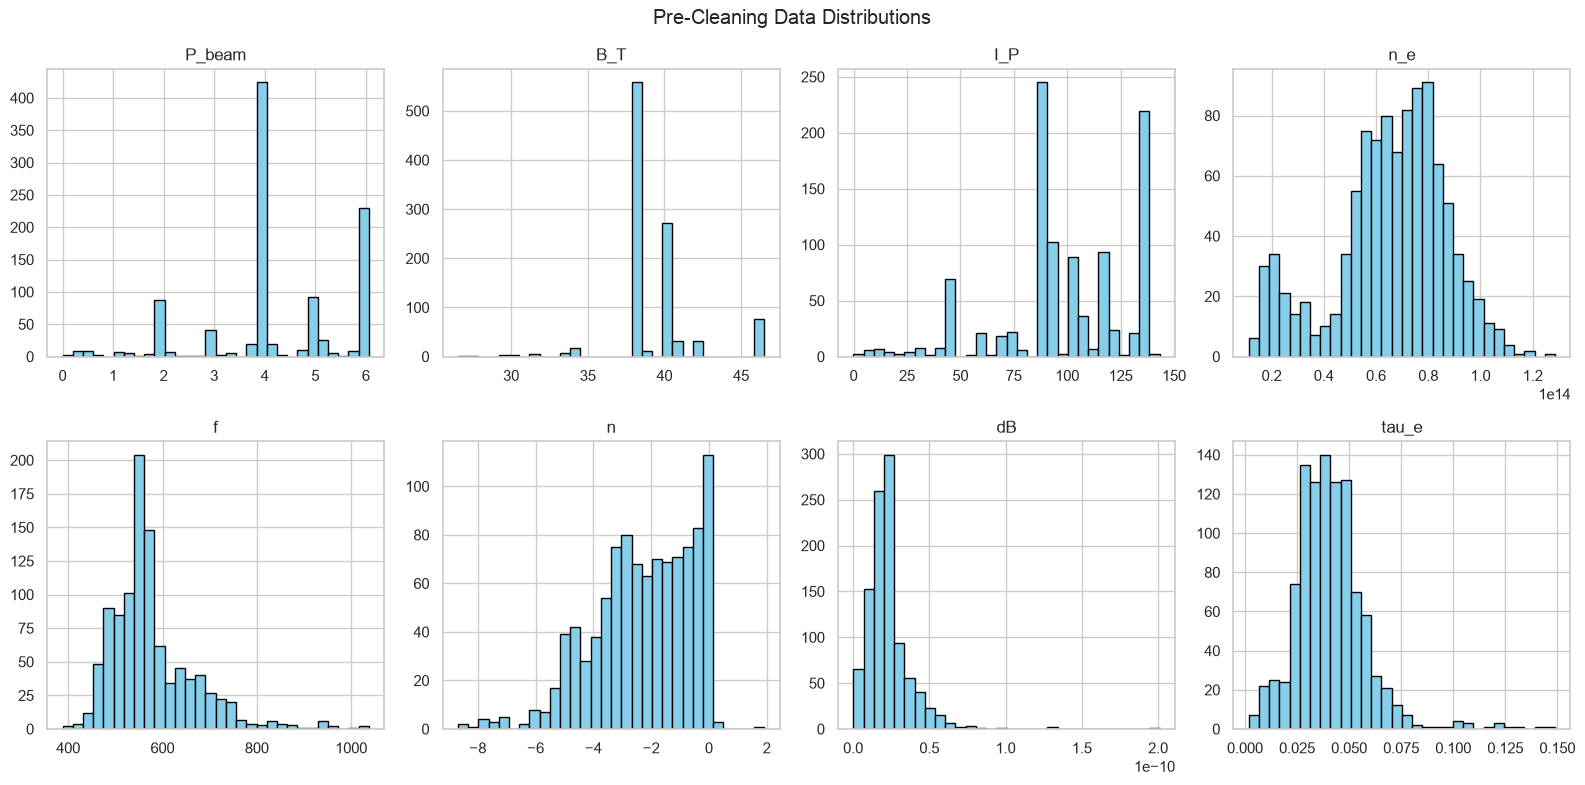

Size after removing extreme outliers (Z > 3): 961 rows

--- Training Stage 1: The 'Wave Predictor' ---
Wave Predictor R^2 Score: 0.550

--- Training Stage 2: The 'Confinement Predictor' ---
Confinement Predictor R^2 Score: 0.371


ValueError: not enough values to unpack (expected 4, got 2)

In [ ]:
if __name__ == "__main__":
    csv_path = "/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv"

    df_raw = load_and_clean_data(filepath=csv_path)
    df_engineered, X_cols, Y_wave_cols, Y_target_col = engineer_features(df_raw)

    model1, model2, scale1, scale2 = train_pipeline(
        df_engineered, X_cols, Y_wave_cols, Y_target_col
    )

    optimize_operating_space(model1, model2, scale1, scale2, X_cols)

Beam Properties


In [ ]:

# --- HELPER FUNCTION ---
def clean_idl_var(arr):
    """Formats IDL byte-order arrays into standard flat numpy arrays."""
    arr = np.asanyarray(arr)
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return arr.flatten().astype(np.float64)

# --- 1. DATA EXTRACTION & CLEANING ---
# Replace with your actual local path
local_path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'
data = readsav(local_path, python_dict=True)

mp_struct = data['mp'][0]

# Features focusing on beam combinations and global parameters
beam_features = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C']
core_features = ['TOTPWR', 'TE', 'NEUTT', 'AVGMODEN', 'NUMCHI']
target_name = 'ETAU'

data_dict = {}
for name in beam_features + core_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

df = pd.DataFrame(data_dict)

# Filter invalid confinement times and extreme outliers
df_clean = df[df[target_name] > 0].copy()
lower_bound = df_clean[target_name].quantile(0.01)
upper_bound = df_clean[target_name].quantile(0.99)
df_clean = df_clean[(df_clean[target_name] >= lower_bound) & (df_clean[target_name] <= upper_bound)]

# --- 2. UNSUPERVISED CLUSTERING (Beam Regimes) ---
# We isolate the injected power of the 3 beams to find injection regimes
X_beams = df_clean[['PBEAM_A', 'PBEAM_B', 'PBEAM_C']]

# Scale before clustering so large power numbers don't warp the distance metrics
scaler_cluster = StandardScaler()
X_beams_scaled = scaler_cluster.fit_transform(X_beams)

# Find 4 distinct beam combinations (you can tune n_clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Beam_Regime'] = kmeans.fit_predict(X_beams_scaled)

# --- 3. SUPERVISED LEARNING (Random Forest) ---
# We predict log10(ETAU) to linearize the power-law physics
y = np.log10(df_clean['ETAU']).values

# Include the cluster labels as a categorical feature
features_for_model = beam_features + core_features + ['Beam_Regime']
X = df_clean[features_for_model].values

# Scale the final feature matrix
scaler_rf = StandardScaler()
X_scaled = scaler_rf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# --- 4. EVALUATION ---
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest R^2 Score (Log10 ETAU): {r2:.4f}")

# Cross-validation for robust scoring
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=kf, scoring='r2')
print(f"5-Fold CV R^2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Random Forest R^2 Score (Log10 ETAU): 0.7243
5-Fold CV R^2: 0.7218 (+/- 0.0379)



--- Physics Profiles of Beam Clusters ---


,PBEAM_A,PBEAM_B,PBEAM_C,TOTPWR,ETAU
Beam_Regime,,,,,
0,1.959372,2.006826,1.960906,3.233517e-11,0.034456
1,1.949516,1.994900,0.291557,1.860025e-11,0.041782
2,1.506521,0.040817,0.729796,1.077573e-11,0.039499
3,-0.000368,1.961538,1.497812,3.083968e-11,0.045673


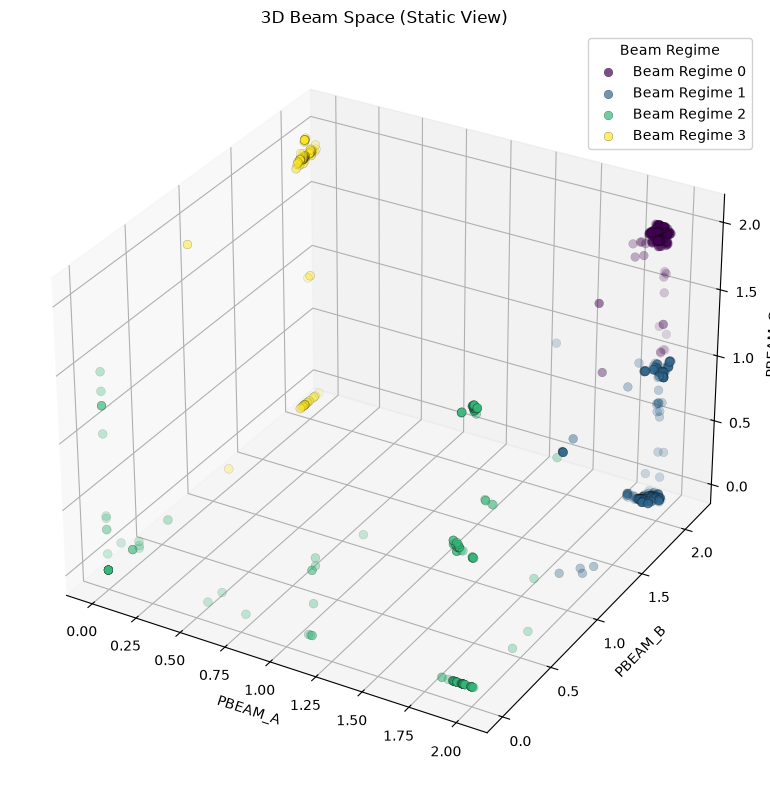

In [ ]:
# ...existing code...
# Group by the new clusters and see the average power distribution
cluster_profiles = df_clean.groupby('Beam_Regime')[['PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'TOTPWR', 'ETAU']].mean()
print("\n--- Physics Profiles of Beam Clusters ---")
display(cluster_profiles)

# Visualize the 3D Beam Space (static, non-interactive)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

regimes = sorted(df_clean['Beam_Regime'].unique())
cmap = plt.cm.viridis

for i, regime in enumerate(regimes):
    subset = df_clean[df_clean['Beam_Regime'] == regime]
    color = cmap(i / (len(regimes) - 1 if len(regimes) > 1 else 1))
    ax.scatter(
        subset['PBEAM_A'],
        subset['PBEAM_B'],
        subset['PBEAM_C'],
        color=color,
        s=40,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.2,
        label=f'Beam Regime {regime}'
    )

ax.set_xlabel('PBEAM_A')
ax.set_ylabel('PBEAM_B')
ax.set_zlabel('PBEAM_C')
ax.set_title('3D Beam Space (Static View)')

ax.legend(title='Beam Regime', loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


--- ETAU summary by Beam Regime ---


,Beam_Regime,n,mean_eta,median_eta,std_eta,q25_eta,q75_eta
0,0,250,0.034456,0.033290,0.009531,0.027282,0.041637
1,1,419,0.041782,0.040832,0.011555,0.033238,0.048464
2,2,179,0.039499,0.039040,0.020435,0.023269,0.054753
3,3,163,0.045673,0.047344,0.016875,0.033258,0.055955


/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/4177646330.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis")


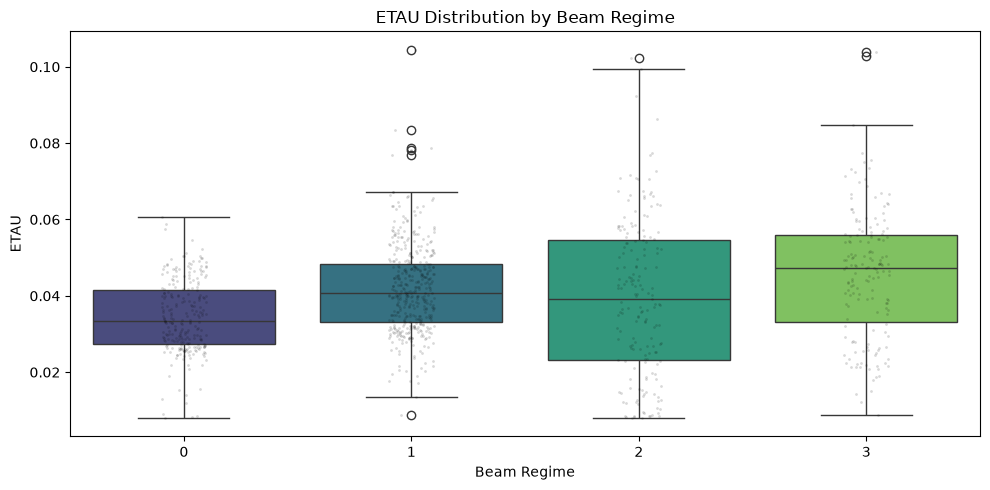

/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/4177646330.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x="Beam_Regime", y="mean_eta", palette="viridis")


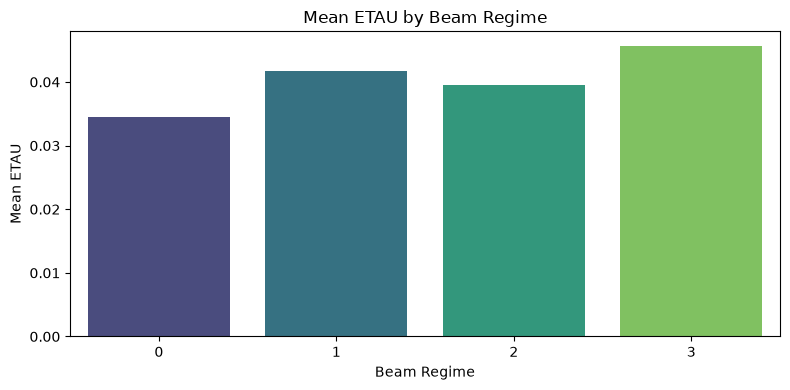

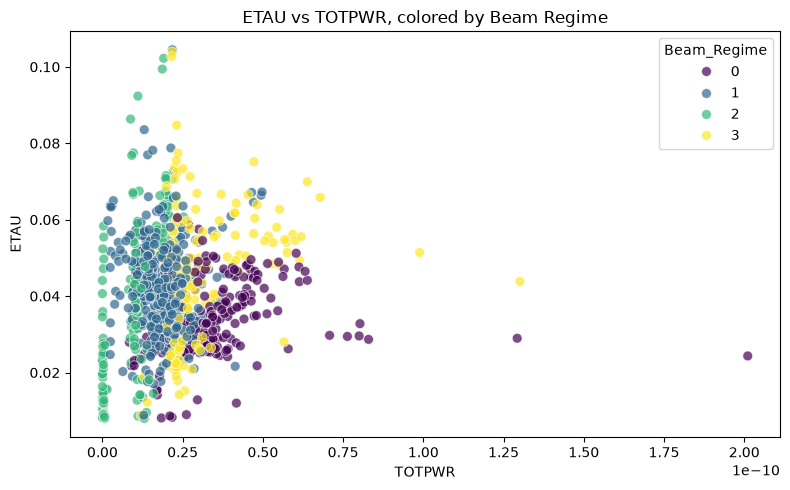

In [ ]:
# Cluster summary with ETAU effect
cluster_summary = (
    df_clean.groupby("Beam_Regime")
    .agg(
        n=("ETAU", "size"),
        mean_eta=("ETAU", "mean"),
        median_eta=("ETAU", "median"),
        std_eta=("ETAU", "std"),
        q25_eta=("ETAU", lambda s: s.quantile(0.25)),
        q75_eta=("ETAU", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

print("\n--- ETAU summary by Beam Regime ---")
display(cluster_summary)

# 1) Boxplot: ETAU distribution by regime
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis")
sns.stripplot(data=df_clean, x="Beam_Regime", y="ETAU", color="black", alpha=0.15, size=2)
plt.title("ETAU Distribution by Beam Regime")
plt.xlabel("Beam Regime")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

# 2) Bar plot: mean ETAU by regime
plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_summary, x="Beam_Regime", y="mean_eta", palette="viridis")
plt.title("Mean ETAU by Beam Regime")
plt.xlabel("Beam Regime")
plt.ylabel("Mean ETAU")
plt.tight_layout()
plt.show()

# 3) Scatter: show how ETAU changes with total power and regime
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="TOTPWR",
    y="ETAU",
    hue="Beam_Regime",
    palette="viridis",
    s=50,
    alpha=0.7
)
plt.title("ETAU vs TOTPWR, colored by Beam Regime")
plt.xlabel("TOTPWR")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

/var/folders/5m/pfmychwd3hv8f9rj7hd207cr0000gn/T/ipykernel_37633/187327427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis", inner="box")


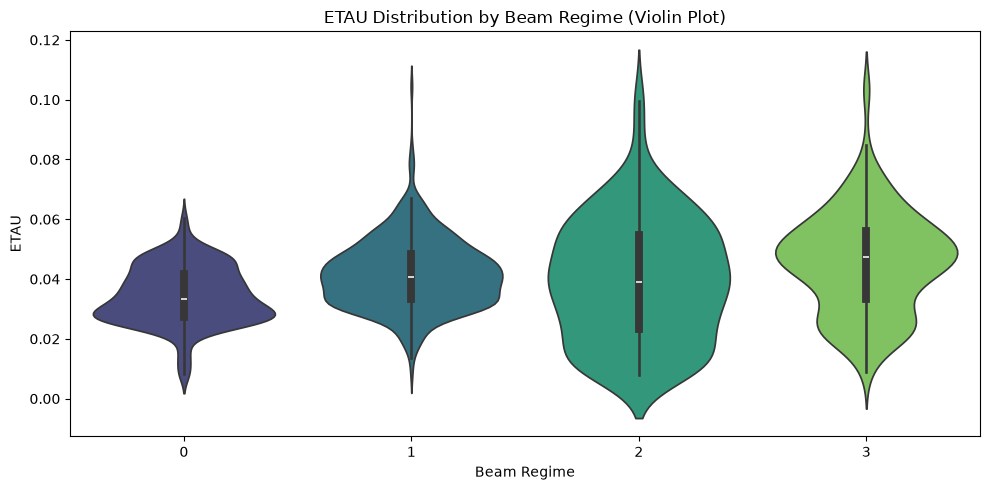

In [ ]:
# 4) Violin plot: ETAU distribution by regime
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_clean, x="Beam_Regime", y="ETAU", palette="viridis", inner="box")
plt.title("ETAU Distribution by Beam Regime (Violin Plot)")
plt.xlabel("Beam Regime")
plt.ylabel("ETAU")
plt.tight_layout()
plt.show()

ETAU R^2: 0.744
ETAU RMSE: 0.007

--- Beam Regime Profiles ---


,PBEAM_A,PBEAM_B,PBEAM_C,TOTPWR,ETAU
Beam_Regime,,,,,
0,1.960898,2.018359,1.744396,3.110876e-11,0.034104
1,1.943355,1.449509,0.432699,1.758936e-11,0.043994
2,-0.000357,1.907873,1.457691,3.023973e-11,0.045113
3,1.161068,0.839172,0.139874,3.338866e-12,0.032435


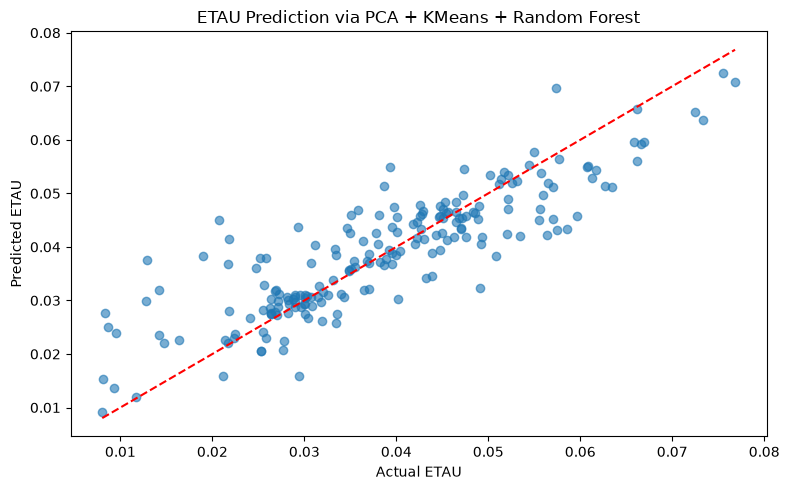

In [ ]:


def clean_idl_var(arr):
    arr = np.asanyarray(arr)
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return arr.flatten().astype(np.float64)

local_path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'
data = readsav(local_path, python_dict=True)

mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

beam_features = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C']
core_features = ['TOTPWR', 'TE', 'NEUTT', 'AVGMODEN', 'NUMCHI']
target_name = 'ETAU'

data_dict = {}
for name in beam_features + core_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

df = pd.DataFrame(data_dict)

df_clean = df[df[target_name] > 0].copy()
lower_bound = df_clean[target_name].quantile(0.01)
upper_bound = df_clean[target_name].quantile(0.99)
df_clean = df_clean[(df_clean[target_name] >= lower_bound) & (df_clean[target_name] <= upper_bound)].reset_index(drop=True)

# Unsupervised feature learning
X_raw = df_clean[beam_features + core_features].astype(float)
X_scaled = StandardScaler().fit_transform(X_raw)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Build the model input from unsupervised components + cluster label
X_model = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
X_model['Beam_Regime'] = cluster_labels

df_clean['Beam_Regime'] = cluster_labels
y = df_clean[target_name].values

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

# Predict ETAU from unsupervised features
reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train, np.log1p(y_train))
pred = np.expm1(reg.predict(X_test))

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"ETAU R^2: {r2:.3f}")
print(f"ETAU RMSE: {rmse:.3f}")

cluster_profiles = (
    df_clean.groupby('Beam_Regime')[beam_features + ['TOTPWR', target_name]]
    .mean()
)
print("\n--- Beam Regime Profiles ---")
display(cluster_profiles)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual ETAU")
plt.ylabel("Predicted ETAU")
plt.title("ETAU Prediction via PCA + KMeans + Random Forest")
plt.tight_layout()
plt.show()